# SmartSupply Insights
## Supply Chain Performance, Delivery Risk & Profitability Analytics

**AICTE | IBM SkillsBuild Data Analytics with AI — Academic Internship 2026**

**Submitted by:** Himani Mane

---

## 1. Executive Summary

This project presents a comprehensive end-to-end data analytics solution applied to the **DataCo SMART SUPPLY CHAIN FOR BIG DATA ANALYSIS** dataset. The dataset contains 180,519 supply-chain transactions spanning January 2015 to January 2018, covering 53 attributes including order details, customer information, product data, shipping modes, delivery performance, and financial metrics.

The analysis uncovers critical drivers of profitability and delivery risk, identifies underperforming product categories and markets, and surfaces actionable operational improvements. A machine learning model for late-delivery risk prediction is developed and evaluated following a rigorous data-leakage audit. All findings are evidence-based, derived solely from the actual dataset.

## 2. Business Problem

Supply-chain organisations face persistent challenges in identifying the root causes of delivery failures, profitability erosion, and operational inefficiency. With thousands of daily transactions, manual inspection is infeasible. This project addresses:

- **Which product categories and markets drive revenue and profit?**
- **What factors are associated with late deliveries?**
- **Where are discounts eroding profitability?**
- **Which regions and markets require operational attention?**
- **Can delivery risk be predicted from pre-shipment data?**

## 3. Project Objectives

1. Understand the supply-chain dataset structure
2. Perform data-quality assessment and cleaning
3. Engineer meaningful analytical features
4. Calculate business KPIs
5. Perform exploratory data analysis across all key dimensions
6. Analyze sales, profitability, customers, products, regions, markets, and shipping
7. Investigate late-delivery patterns
8. Build and evaluate machine learning models for delivery risk prediction
9. Generate professional visualizations
10. Produce evidence-based business recommendations

## 4. Dataset Description

| Attribute | Value |
|-----------|-------|
| Dataset Name | DataCo SMART SUPPLY CHAIN FOR BIG DATA ANALYSIS |
| Total Records | 180,519 |
| Total Features | 53 |
| Date Range | January 2015 – January 2018 |
| Markets Covered | Africa, Europe, LATAM, Pacific Asia, USCA |
| Customer Segments | Consumer, Corporate, Home Office |
| Shipping Modes | Standard Class, First Class, Second Class, Same Day |

## 5. Dataset Source and Attribution

- **Kaggle:** https://www.kaggle.com/datasets/alinoranianesfahani/dataco-smart-supply-chain-for-big-data-analysis
- **Original Source:** https://data.mendeley.com/datasets/8gx2fvg2k6/5
- **DOI:** 10.17632/8gx2fvg2k6.5
- **License:** Creative Commons Attribution 4.0 International

## 6. Import Libraries

In [9]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, ConfusionMatrixDisplay
)
from sklearn.dummy import DummyClassifier

warnings.filterwarnings('ignore')
print('Libraries loaded successfully.')
print(f'Pandas: {pd.__version__}')
print(f'NumPy: {np.__version__}')
print(f'Matplotlib: {matplotlib.__version__}')
print(f'Seaborn: {sns.__version__}')

Libraries loaded successfully.
Pandas: 3.0.2
NumPy: 2.4.4
Matplotlib: 3.11.2
Seaborn: 0.13.2


## 7. Configuration

In [10]:
# ── Paths (relative — works on any machine) ──────────────────────────────────
DATA_DIR   = Path('data')
IMG_DIR    = Path('analysis_images')
DATA_FILE  = DATA_DIR / 'DataCoSupplyChainDataset.csv'
DESC_FILE  = DATA_DIR / 'DescriptionDataCoSupplyChain.csv'

IMG_DIR.mkdir(parents=True, exist_ok=True)

# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'      : 150,
    'savefig.dpi'     : 300,
    'font.size'       : 11,
    'axes.titlesize'  : 13,
    'axes.labelsize'  : 11,
    'xtick.labelsize' : 9,
    'ytick.labelsize' : 9,
    'legend.fontsize' : 9,
    'figure.facecolor': 'white',
    'axes.facecolor'  : 'white',
    'axes.grid'       : True,
    'grid.alpha'      : 0.3,
})
PALETTE = 'Blues_d'
ACCENT  = '#2c7bb6'

def save_fig(name: str):
    """Save current figure to analysis_images/."""
    path = IMG_DIR / name
    plt.savefig(path, dpi=300, bbox_inches='tight')
    print(f'  Saved → {path}')

print('Configuration complete. Image directory:', IMG_DIR)

Configuration complete. Image directory: analysis_images


## 8. Data Loading

In [11]:
df_raw = pd.read_csv(DATA_FILE, encoding='latin-1')
print(f'Dataset loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
df_raw.head(3)

Dataset loaded: 180,519 rows × 53 columns


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class


## 9. Data Understanding

In [12]:
print('=== DATASET SHAPE ===')
print(f'Rows   : {df_raw.shape[0]:,}')
print(f'Columns: {df_raw.shape[1]}')

print('\n=== COLUMN DATA TYPES ===')
dtype_df = pd.DataFrame({
    'Column': df_raw.columns,
    'Dtype' : df_raw.dtypes.values,
    'Non-Null Count': df_raw.notnull().sum().values,
    'Null Count'    : df_raw.isnull().sum().values,
    'Null %'        : (df_raw.isnull().mean() * 100).round(2).values,
    'Unique Values' : df_raw.nunique().values
})
display(dtype_df)

=== DATASET SHAPE ===
Rows   : 180,519
Columns: 53

=== COLUMN DATA TYPES ===


,Column,Dtype,Non-Null Count,Null Count,Null %,Unique Values
0,Type,str,180519,0,0.00,4
1,Days for shipping (real),int64,180519,0,0.00,7
2,Days for shipment (scheduled),int64,180519,0,0.00,4
3,Benefit per order,float64,180519,0,0.00,21998
4,Sales per customer,float64,180519,0,0.00,2927
5,Delivery Status,str,180519,0,0.00,4
6,Late_delivery_risk,int64,180519,0,0.00,2
7,Category Id,int64,180519,0,0.00,51
8,Category Name,str,180519,0,0.00,50
9,Customer City,str,180519,0,0.00,563


In [13]:
print('=== DESCRIPTIVE STATISTICS — NUMERICAL COLUMNS ===')
display(df_raw.describe().round(2))

=== DESCRIPTIVE STATISTICS — NUMERICAL COLUMNS ===


,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Price,Product Status
count,180519.00,180519.00,180519.00,180519.00,180519.00,180519.00,180519.00,180516.00,180519.00,180519.00,...,180519.00,180519.00,180519.00,180519.00,24840.00,180519.00,180519.00,0.0,180519.00,180519.0
mean,3.50,2.93,21.97,183.11,0.55,31.85,6691.38,35921.13,5.44,29.72,...,2.13,203.77,183.11,21.97,55426.13,692.51,31.85,NaN,141.23,0.0
std,1.62,1.37,104.43,120.04,0.50,15.64,4162.92,37542.46,1.63,9.81,...,1.45,132.27,120.04,104.43,31919.28,336.45,15.64,NaN,139.73,0.0
min,0.00,0.00,-4274.98,7.49,0.00,2.00,1.00,603.00,2.00,-33.94,...,1.00,9.99,7.49,-4274.98,1040.00,19.00,2.00,NaN,9.99,0.0
25%,2.00,2.00,7.00,104.38,0.00,18.00,3258.50,725.00,4.00,18.27,...,1.00,119.98,104.38,7.00,23464.00,403.00,18.00,NaN,50.00,0.0
50%,3.00,4.00,31.52,163.99,1.00,29.00,6457.00,19380.00,5.00,33.14,...,1.00,199.92,163.99,31.52,59405.00,627.00,29.00,NaN,59.99,0.0
75%,5.00,4.00,64.80,247.40,1.00,45.00,9779.00,78207.00,7.00,39.28,...,3.00,299.95,247.40,64.80,90008.00,1004.00,45.00,NaN,199.99,0.0
max,6.00,4.00,911.80,1939.99,1.00,76.00,20757.00,99205.00,12.00,48.78,...,5.00,1999.99,1939.99,911.80,99301.00,1363.00,76.00,NaN,1999.99,0.0


In [14]:
print('=== CATEGORICAL COLUMNS — VALUE DISTRIBUTIONS ===')
cat_cols = df_raw.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    vc = df_raw[col].value_counts(dropna=False)
    if len(vc) <= 20:
        print(f'\n{col} ({len(vc)} unique):')
        print(vc.to_string())

=== CATEGORICAL COLUMNS — VALUE DISTRIBUTIONS ===

Type (4 unique):
Type
DEBIT       69295
TRANSFER    49883
PAYMENT     41725
CASH        19616

Delivery Status (4 unique):
Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754

Customer Country (2 unique):
Customer Country
EE. UU.        111146
Puerto Rico     69373

Customer Email (1 unique):
Customer Email
XXXXXXXXX    180519

Customer Password (1 unique):
Customer Password
XXXXXXXXX    180519

Customer Segment (3 unique):
Customer Segment
Consumer       93504
Corporate      54789
Home Office    32226

Department Name (11 unique):
Department Name
Fan Shop              66861
Apparel               48998
Golf                  33220
Footwear              14525
Outdoors               9686
Fitness                2479
Discs Shop             2026
Technology             1465
Pet Shop                492
Book Shop               405
Health and Beauty       362

Market (5 uniq

In [15]:
# Data Dictionary
desc = pd.read_csv(DESC_FILE, encoding='latin-1')
desc.columns = ['Field', 'Description']
desc['Field']       = desc['Field'].str.strip()
desc['Description'] = desc['Description'].str.replace(r'^\s*:\s*', '', regex=True).str.strip()
print('=== DATA DICTIONARY ===')
display(desc)

=== DATA DICTIONARY ===


,Field,Description
0,Type,Type of transaction made
1,Days for shipping (real),Actual shipping days of the purchased product
2,Days for shipment (scheduled),Days of scheduled delivery of the purchased pr...
3,Benefit per order,Earnings per order placed
4,Sales per customer,Total sales per customer made per customer
5,Delivery Status,"Delivery status of orders: Advance shipping , ..."
6,Late_delivery_risk,Categorical variable that indicates if sending...
7,Category Id,Product category code
8,Category Name,Description of the product category
9,Customer City,City where the customer made the purchase


## 10. Data Quality Assessment

In [16]:
print('=== MISSING VALUES SUMMARY ===')
mv = df_raw.isnull().sum()
mv_pct = (df_raw.isnull().mean() * 100).round(2)
mv_df = pd.DataFrame({'Missing Count': mv, 'Missing %': mv_pct})
mv_df = mv_df[mv_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
display(mv_df)

print(f'\n=== DUPLICATES ===')
dups = df_raw.duplicated().sum()
print(f'Duplicate rows: {dups}')

print(f'\n=== NEGATIVE PROFIT ORDERS ===')
neg_profit = (df_raw['Order Profit Per Order'] < 0).sum()
print(f'Orders with negative profit: {neg_profit:,} ({neg_profit/len(df_raw)*100:.1f}%)')

print(f'\n=== ZERO-SALES ORDERS ===')
zero_sales = (df_raw['Sales'] <= 0).sum()
print(f'Orders with zero/negative sales: {zero_sales}')

print(f'\n=== SHIPPING DAYS RANGE ===')
print(f'Days for shipping (real) - min: {df_raw["Days for shipping (real)"].min()}, max: {df_raw["Days for shipping (real)"].max()}')
print(f'Days for shipment (scheduled) - min: {df_raw["Days for shipment (scheduled)"].min()}, max: {df_raw["Days for shipment (scheduled)"].max()}')

=== MISSING VALUES SUMMARY ===


,Missing Count,Missing %
Product Description,180519,100.00
Order Zipcode,155679,86.24
Customer Zipcode,3,0.00
Customer Lname,8,0.00



=== DUPLICATES ===
Duplicate rows: 0

=== NEGATIVE PROFIT ORDERS ===
Orders with negative profit: 33,784 (18.7%)

=== ZERO-SALES ORDERS ===
Orders with zero/negative sales: 0

=== SHIPPING DAYS RANGE ===
Days for shipping (real) - min: 0, max: 6
Days for shipment (scheduled) - min: 0, max: 4


In [17]:
# Data Quality Summary Table
dq_summary = pd.DataFrame([
    {'Issue': 'Customer Lname missing', 'Count': 8, 'Pct': '< 0.01%', 'Impact': 'Negligible — identifier only', 'Action': 'Leave as-is'},
    {'Issue': 'Customer Zipcode missing', 'Count': 3, 'Pct': '< 0.01%', 'Impact': 'Negligible', 'Action': 'Leave as-is'},
    {'Issue': 'Order Zipcode missing', 'Count': 155679, 'Pct': '86.2%', 'Impact': 'Not used in analysis', 'Action': 'Exclude column'},
    {'Issue': 'Product Description missing', 'Count': 180519, 'Pct': '100%', 'Impact': 'Entire column empty', 'Action': 'Drop column'},
    {'Issue': 'Negative profit orders', 'Count': neg_profit, 'Pct': f'{neg_profit/len(df_raw)*100:.1f}%', 'Impact': 'Profitability insight', 'Action': 'Retain — valid business data'},
    {'Issue': 'Duplicate rows', 'Count': 0, 'Pct': '0%', 'Impact': 'None', 'Action': 'None required'},
])
display(dq_summary)

,Issue,Count,Pct,Impact,Action
0,Customer Lname missing,8,< 0.01%,Negligible — identifier only,Leave as-is
1,Customer Zipcode missing,3,< 0.01%,Negligible,Leave as-is
2,Order Zipcode missing,155679,86.2%,Not used in analysis,Exclude column
3,Product Description missing,180519,100%,Entire column empty,Drop column
4,Negative profit orders,33784,18.7%,Profitability insight,Retain — valid business data
5,Duplicate rows,0,0%,None,None required


## 11. Data Cleaning

In [18]:
df = df_raw.copy()

# 1. Drop fully-empty column
df.drop(columns=['Product Description'], inplace=True)
print('Dropped: Product Description (100% missing)')

# 2. Drop Order Zipcode (86% missing, not used in analysis)
df.drop(columns=['Order Zipcode'], inplace=True)
print('Dropped: Order Zipcode (86% missing)')

# 3. Drop PII / non-analytical columns
pii_cols = ['Customer Email', 'Customer Password', 'Customer Street',
            'Customer Fname', 'Customer Lname', 'Product Image']
df.drop(columns=pii_cols, inplace=True)
print(f'Dropped PII/non-analytical columns: {pii_cols}')

# 4. Parse dates
df['order_date']    = pd.to_datetime(df['order date (DateOrders)'],    format='%m/%d/%Y %H:%M', errors='coerce')
df['shipping_date'] = pd.to_datetime(df['shipping date (DateOrders)'], format='%m/%d/%Y %H:%M', errors='coerce')
print('Parsed: order_date, shipping_date')

# 5. Strip whitespace from string columns
str_cols = df.select_dtypes(include='object').columns
for c in str_cols:
    df[c] = df[c].str.strip()
print('Stripped whitespace from all string columns')

# 6. Fill the 3 missing Customer Zipcode with 0 (not used in analysis)
df['Customer Zipcode'] = df['Customer Zipcode'].fillna(0)

print(f'\nCleaned dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')

Dropped: Product Description (100% missing)
Dropped: Order Zipcode (86% missing)
Dropped PII/non-analytical columns: ['Customer Email', 'Customer Password', 'Customer Street', 'Customer Fname', 'Customer Lname', 'Product Image']
Parsed: order_date, shipping_date
Stripped whitespace from all string columns

Cleaned dataset shape: 180,519 rows × 47 columns


## 12. Feature Engineering

In [19]:
# Time features
df['order_year']    = df['order_date'].dt.year
df['order_month']   = df['order_date'].dt.month
df['order_quarter'] = df['order_date'].dt.quarter
df['order_yearmonth'] = df['order_date'].dt.to_period('M')

# Delivery features
df['delivery_delay'] = df['Days for shipping (real)'] - df['Days for shipment (scheduled)']
df['is_late']        = (df['delivery_delay'] > 0).astype(int)

# Profit margin per item
df['profit_margin_pct'] = df['Order Item Profit Ratio'] * 100

# Discount amount
df['discount_amount'] = df['Order Item Discount']

# Shipping cost proxy: difference between product price and sales
# (Sales per customer vs Order Item Total)
df['order_value'] = df['Sales']

print('Engineered features:')
eng_feats = ['order_year','order_month','order_quarter','delivery_delay',
             'is_late','profit_margin_pct','discount_amount','order_value']
display(df[eng_feats].describe().round(2))

print(f'\nis_late distribution:')
print(df['is_late'].value_counts())
print(f'Late delivery rate (engineered): {df["is_late"].mean()*100:.1f}%')
print(f'Late_delivery_risk (original):   {df["Late_delivery_risk"].mean()*100:.1f}%')

Engineered features:


,order_year,order_month,order_quarter,delivery_delay,is_late,profit_margin_pct,discount_amount,order_value
count,180519.00,180519.00,180519.00,180519.00,180519.00,180519.00,180519.00,180519.00
mean,2015.97,6.24,2.42,0.57,0.57,12.06,20.66,203.77
std,0.83,3.40,1.10,1.49,0.49,46.68,21.80,132.27
min,2015.00,1.00,1.00,-2.00,0.00,-275.00,0.00,9.99
25%,2015.00,3.00,1.00,0.00,0.00,8.00,5.40,119.98
50%,2016.00,6.00,2.00,1.00,1.00,27.00,14.00,199.92
75%,2017.00,9.00,3.00,1.00,1.00,36.00,29.99,299.95
max,2018.00,12.00,4.00,4.00,1.00,50.00,500.00,1999.99



is_late distribution:
is_late
1    103400
0     77119
Name: count, dtype: int64
Late delivery rate (engineered): 57.3%
Late_delivery_risk (original):   54.8%


## 13. KPI Analysis

In [20]:
kpis = {
    'Total Sales ($)'              : df['Sales'].sum(),
    'Total Profit ($)'             : df['Order Profit Per Order'].sum(),
    'Total Orders'                 : df['Order Id'].nunique(),
    'Total Order Items'            : len(df),
    'Total Quantity Sold'          : df['Order Item Quantity'].sum(),
    'Avg Order Value ($)'          : df['Sales'].mean(),
    'Avg Profit Per Item ($)'      : df['Order Profit Per Order'].mean(),
    'Overall Profit Margin (%)'    : (df['Order Profit Per Order'].sum() / df['Sales'].sum() * 100),
    'Avg Discount Rate (%)'        : df['Order Item Discount Rate'].mean() * 100,
    'Late Delivery Rate (%)'       : df['Late_delivery_risk'].mean() * 100,
    'Avg Actual Shipping Days'     : df['Days for shipping (real)'].mean(),
    'Avg Scheduled Shipping Days'  : df['Days for shipment (scheduled)'].mean(),
    'Negative Profit Orders'       : (df['Order Profit Per Order'] < 0).sum(),
    'Unique Products'              : df['Product Name'].nunique(),
    'Unique Customers'             : df['Customer Id'].nunique(),
    'Unique Countries'             : df['Order Country'].nunique(),
}

kpi_df = pd.DataFrame(list(kpis.items()), columns=['KPI', 'Value'])
kpi_df['Value'] = kpi_df['Value'].apply(lambda x: f'{x:,.2f}' if isinstance(x, float) else f'{x:,}')
print('=== KEY PERFORMANCE INDICATORS ===')
display(kpi_df)

=== KEY PERFORMANCE INDICATORS ===


,KPI,Value
0,Total Sales ($),"36,784,735.01"
1,Total Profit ($),"3,966,902.97"
2,Total Orders,"65,752.00"
3,Total Order Items,"180,519.00"
4,Total Quantity Sold,"384,079.00"
5,Avg Order Value ($),203.77
6,Avg Profit Per Item ($),21.97
7,Overall Profit Margin (%),10.78
8,Avg Discount Rate (%),10.17
9,Late Delivery Rate (%),54.83


## 14. Exploratory Data Analysis

  Saved → analysis_images\numerical_distributions.png


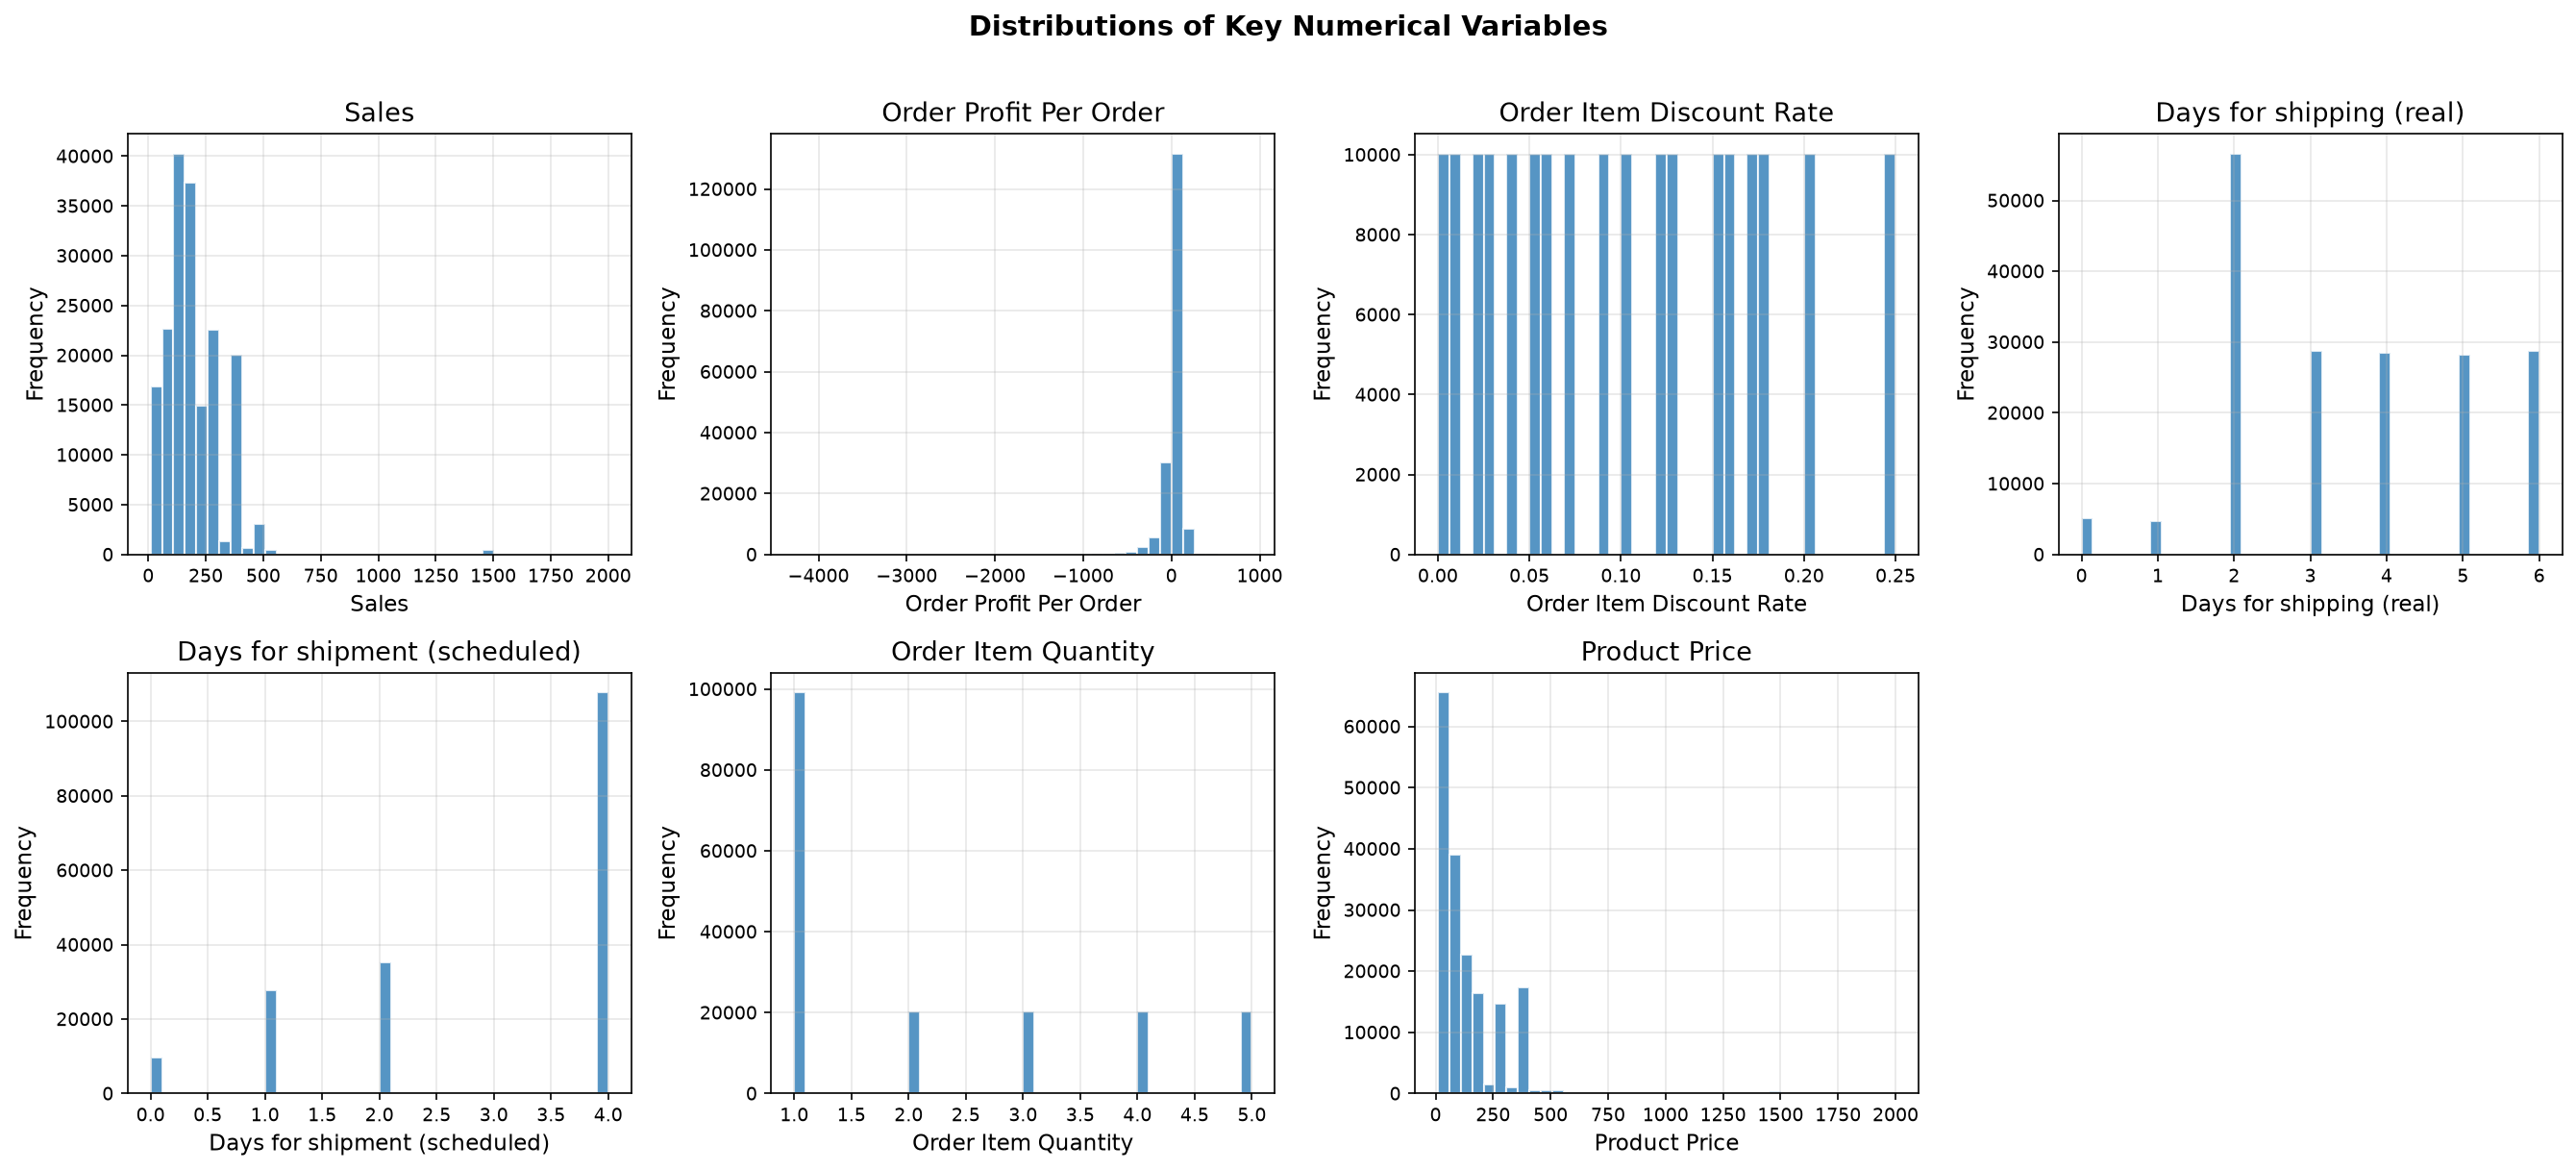

In [21]:
# Numerical distributions
num_cols = ['Sales', 'Order Profit Per Order', 'Order Item Discount Rate',
            'Days for shipping (real)', 'Days for shipment (scheduled)',
            'Order Item Quantity', 'Product Price']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=40, color=ACCENT, edgecolor='white', alpha=0.8)
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
axes[-1].set_visible(False)
plt.suptitle('Distributions of Key Numerical Variables', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
save_fig('numerical_distributions.png')
plt.show()

## 15. Sales Analysis

### Analytical Question
Which product categories, regions, markets, and customer segments drive sales?

  Saved → analysis_images\sales_by_category.png


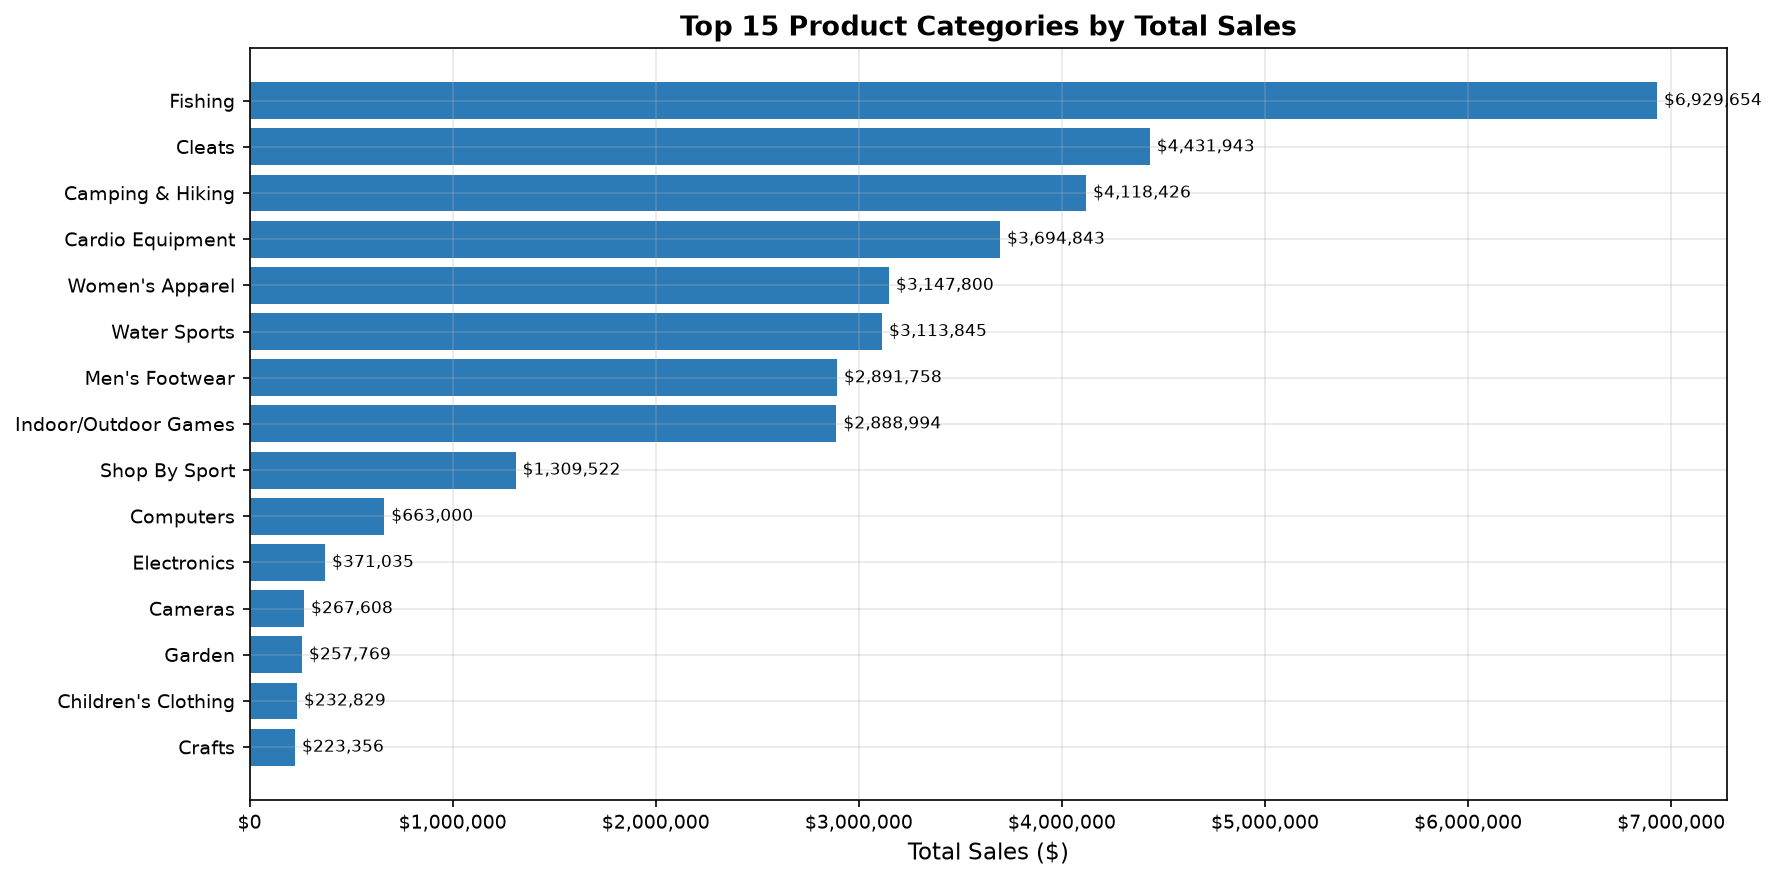

Top 5 categories by sales:
Category Name
Fishing             6.929654e+06
Cleats              4.431943e+06
Camping & Hiking    4.118426e+06
Cardio Equipment    3.694843e+06
Women's Apparel     3.147800e+06


In [22]:
# --- Sales by Category ---
sales_cat = df.groupby('Category Name')['Sales'].sum().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(sales_cat.index[::-1], sales_cat.values[::-1], color=ACCENT)
ax.set_xlabel('Total Sales ($)')
ax.set_title('Top 15 Product Categories by Total Sales', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for bar, val in zip(bars, sales_cat.values[::-1]):
    ax.text(val + sales_cat.max()*0.005, bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}', va='center', fontsize=8)
plt.tight_layout()
save_fig('sales_by_category.png')
plt.show()
print('Top 5 categories by sales:')
print(sales_cat.head().to_string())

  Saved → analysis_images\sales_trend.png


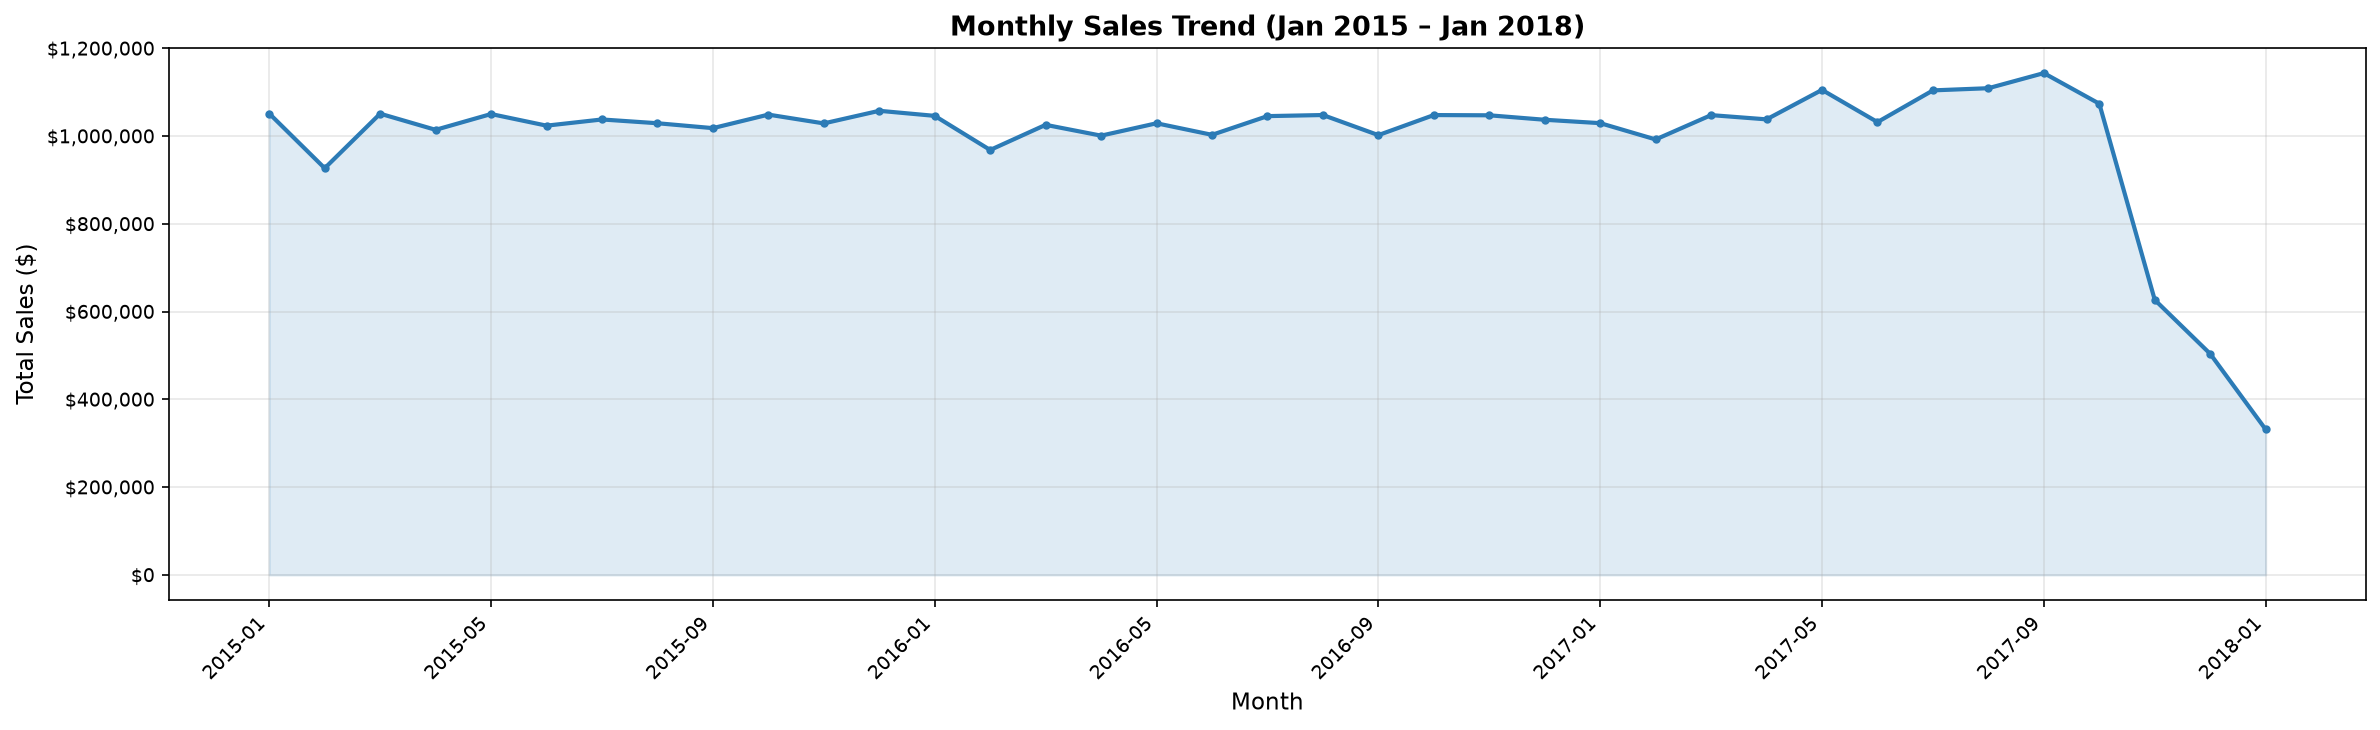

In [23]:
# --- Monthly Sales Trend ---
monthly_sales = df.groupby('order_yearmonth')['Sales'].sum().reset_index()
monthly_sales['order_yearmonth'] = monthly_sales['order_yearmonth'].astype(str)

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(monthly_sales['order_yearmonth'], monthly_sales['Sales'], color=ACCENT, linewidth=2, marker='o', markersize=3)
ax.fill_between(monthly_sales['order_yearmonth'], monthly_sales['Sales'], alpha=0.15, color=ACCENT)
ax.set_xlabel('Month')
ax.set_ylabel('Total Sales ($)')
ax.set_title('Monthly Sales Trend (Jan 2015 – Jan 2018)', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
tick_positions = list(range(0, len(monthly_sales), 4))
ax.set_xticks(tick_positions)
ax.set_xticklabels([monthly_sales['order_yearmonth'].iloc[i] for i in tick_positions], rotation=45, ha='right')
plt.tight_layout()
save_fig('sales_trend.png')
plt.show()

  Saved → analysis_images\sales_by_region.png


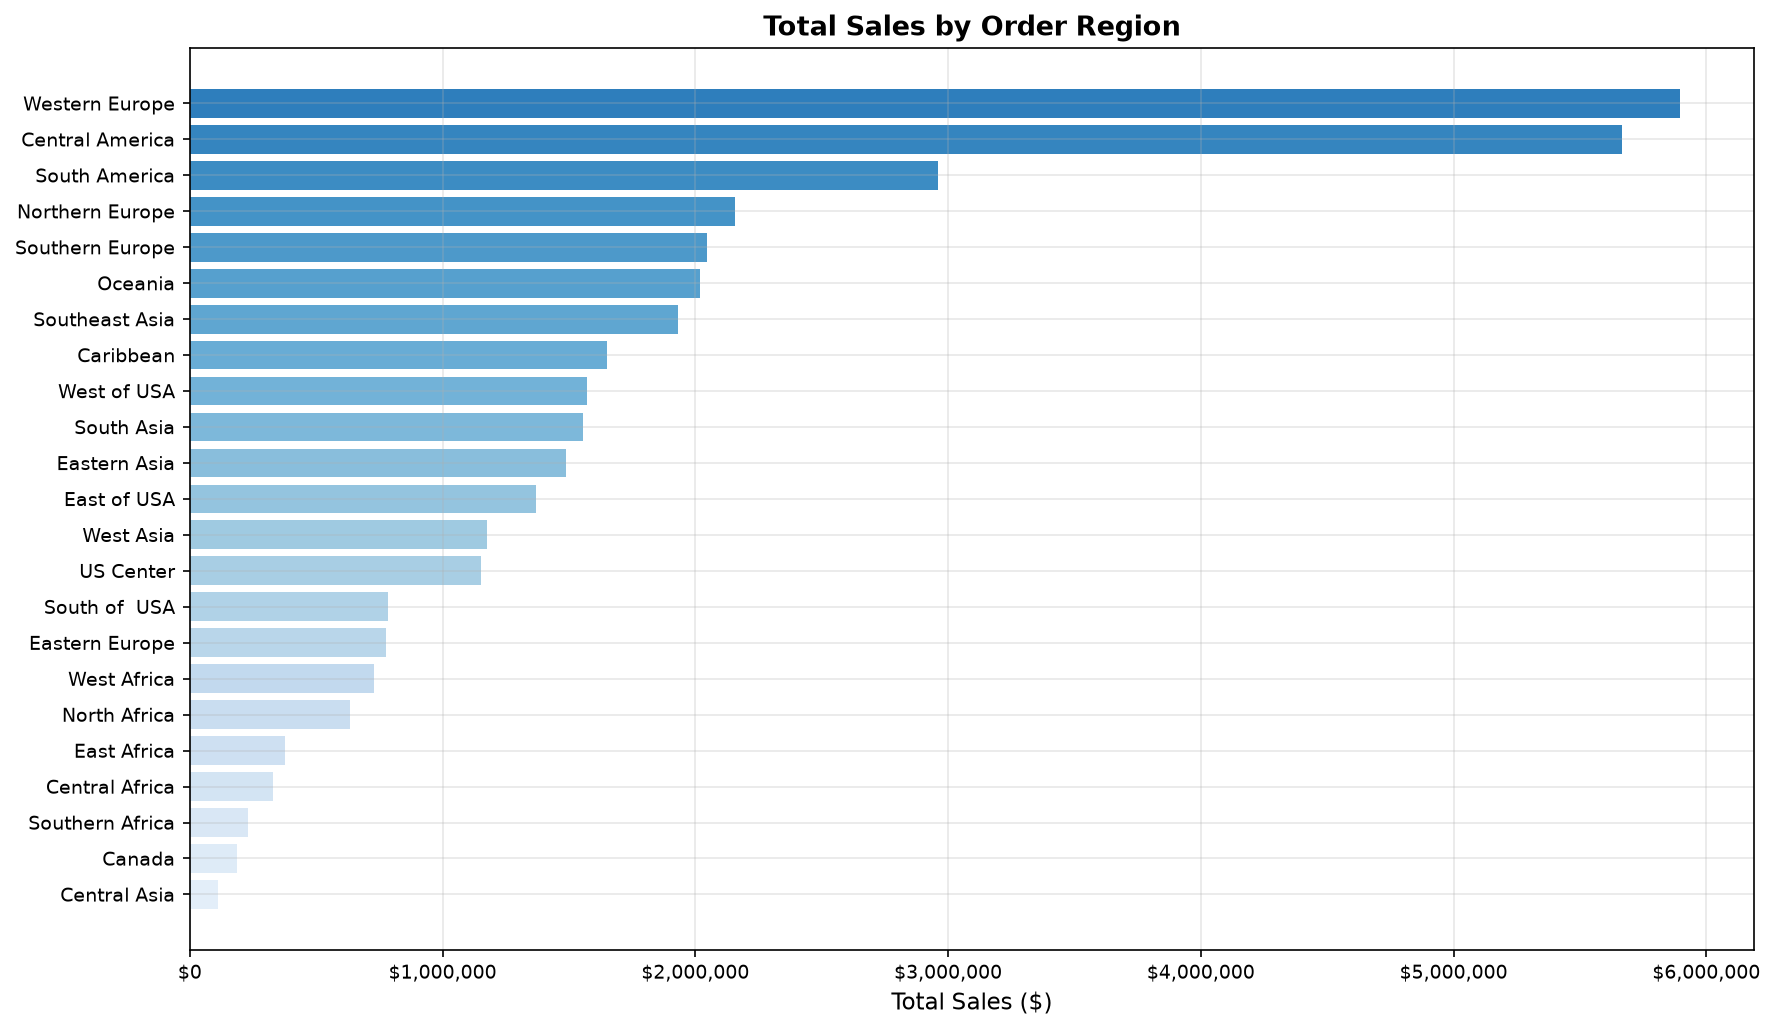

Order Region
Western Europe     5.894381e+06
Central America    5.665712e+06
South America      2.960881e+06
Northern Europe    2.155831e+06
Southern Europe    2.047919e+06
Oceania            2.016654e+06
Southeast Asia     1.932496e+06
Caribbean          1.651019e+06
West of USA        1.571416e+06
South Asia         1.553681e+06
Eastern Asia       1.486401e+06
East of USA        1.371112e+06
West Asia          1.174672e+06
US Center          1.151356e+06
South of  USA      7.857839e+05
Eastern Europe     7.742666e+05
West Africa        7.279512e+05
North Africa       6.347522e+05
East Africa        3.762349e+05
Central Africa     3.272630e+05
Southern Africa    2.282516e+05
Canada             1.868610e+05
Central Asia       1.098399e+05


In [24]:
# --- Sales by Region ---
sales_region = df.groupby('Order Region')['Sales'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))
colors = plt.cm.Blues_r(np.linspace(0.3, 0.9, len(sales_region)))
ax.barh(sales_region.index[::-1], sales_region.values[::-1], color=colors[::-1])
ax.set_xlabel('Total Sales ($)')
ax.set_title('Total Sales by Order Region', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
save_fig('sales_by_region.png')
plt.show()
print(sales_region.to_string())

  Saved → analysis_images\sales_by_market.png


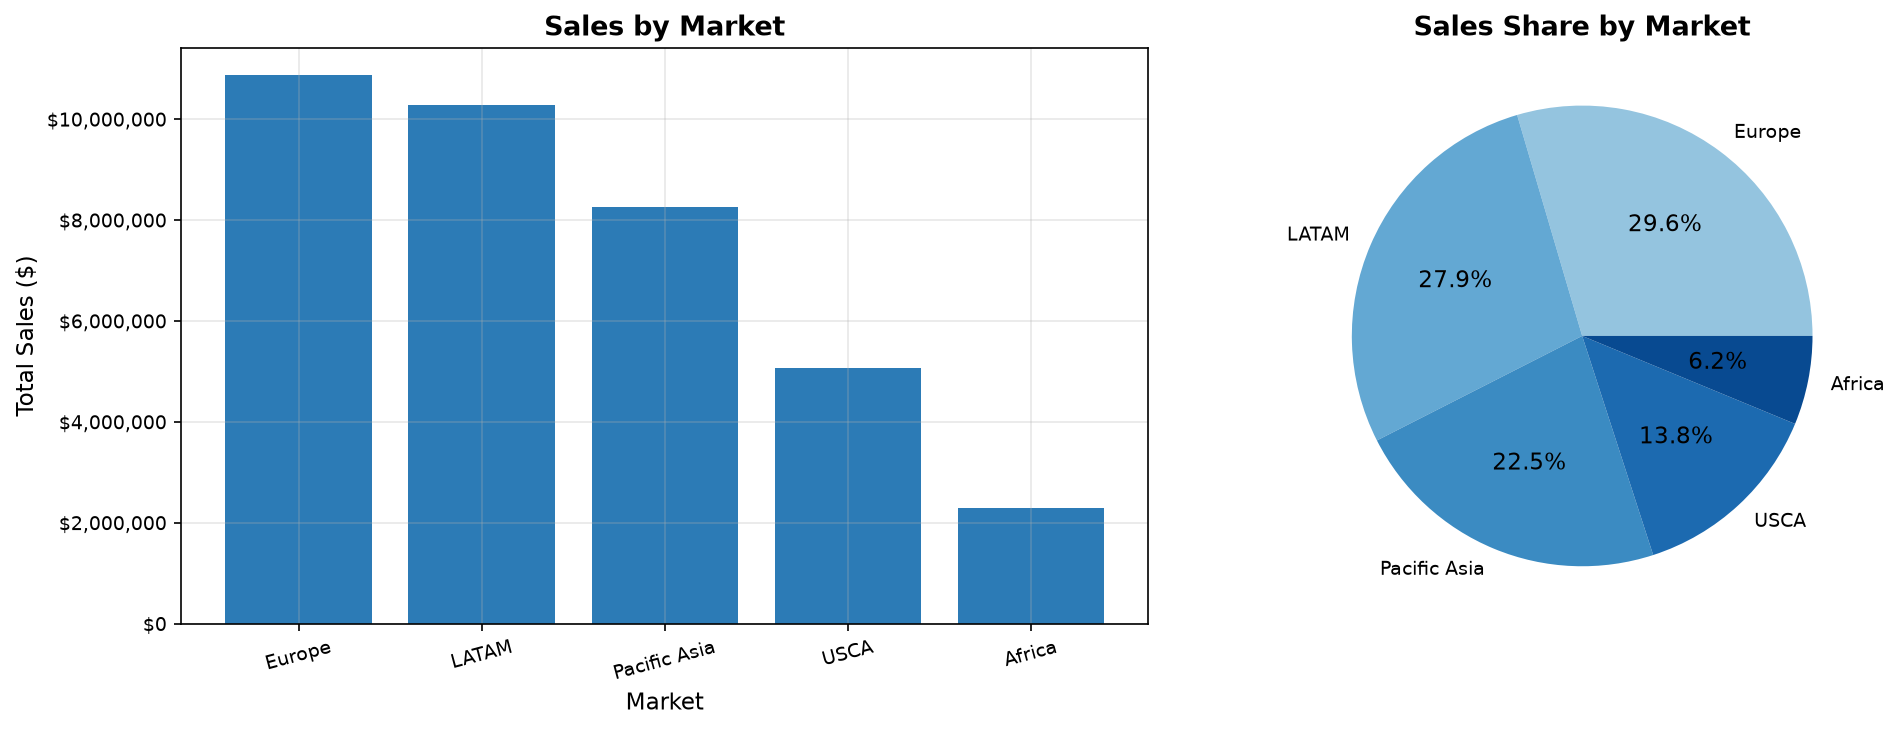

Market
Europe          1.087240e+07
LATAM           1.027761e+07
Pacific Asia    8.273744e+06
USCA            5.066529e+06
Africa          2.294453e+06


In [25]:
# --- Sales by Market ---
sales_market = df.groupby('Market')['Sales'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(sales_market.index, sales_market.values, color=ACCENT)
axes[0].set_xlabel('Market')
axes[0].set_ylabel('Total Sales ($)')
axes[0].set_title('Sales by Market', fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].tick_params(axis='x', rotation=15)

wedges, texts, autotexts = axes[1].pie(
    sales_market.values, labels=sales_market.index,
    autopct='%1.1f%%', colors=plt.cm.Blues(np.linspace(0.4, 0.9, len(sales_market))))
axes[1].set_title('Sales Share by Market', fontweight='bold')
plt.tight_layout()
save_fig('sales_by_market.png')
plt.show()
print(sales_market.to_string())

  Saved → analysis_images\customer_segment_distribution.png


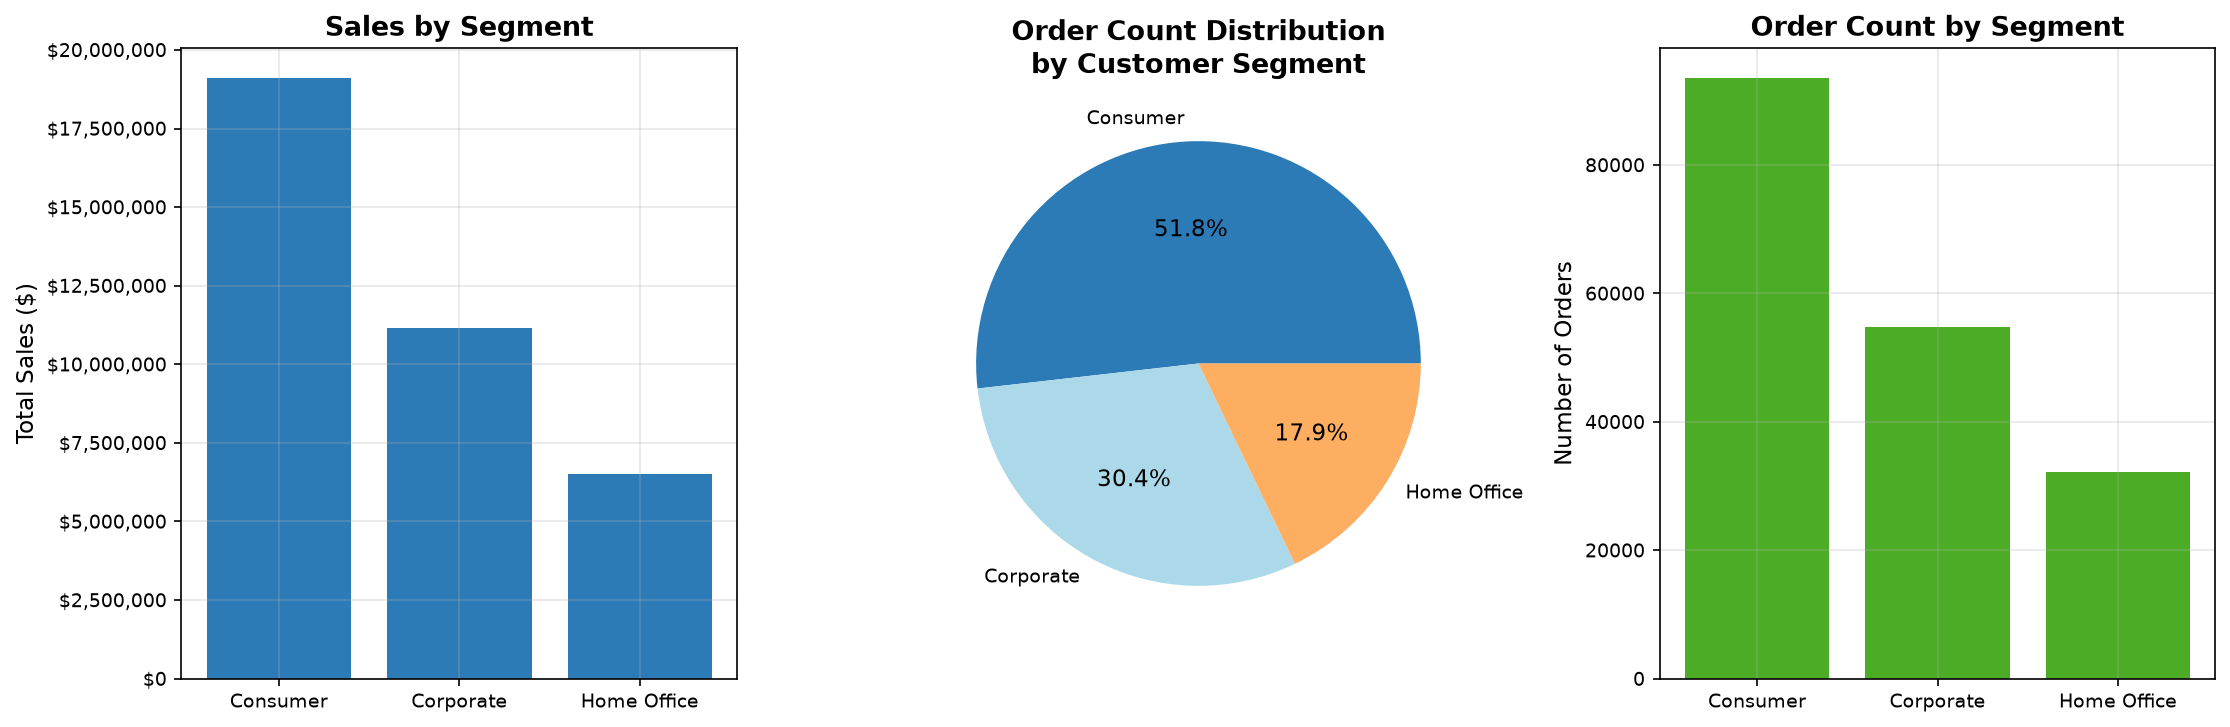

Sales by Segment:
Customer Segment
Consumer       1.909579e+07
Corporate      1.116841e+07
Home Office    6.520538e+06


In [26]:
# --- Sales by Customer Segment ---
sales_seg = df.groupby('Customer Segment')['Sales'].sum().sort_values(ascending=False)
counts_seg = df.groupby('Customer Segment')['Order Id'].count().sort_values(ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].bar(sales_seg.index, sales_seg.values, color=ACCENT)
axes[0].set_title('Sales by Segment', fontweight='bold')
axes[0].set_ylabel('Total Sales ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

axes[1].pie(counts_seg.values, labels=counts_seg.index, autopct='%1.1f%%',
            colors=['#2c7bb6','#abd9e9','#fdae61'])
axes[1].set_title('Order Count Distribution\nby Customer Segment', fontweight='bold')

axes[2].bar(counts_seg.index, counts_seg.values, color='#4dac26')
axes[2].set_title('Order Count by Segment', fontweight='bold')
axes[2].set_ylabel('Number of Orders')
plt.tight_layout()
save_fig('customer_segment_distribution.png')
plt.show()
print('Sales by Segment:')
print(sales_seg.to_string())

## 16. Profitability Analysis

### Analytical Question
Which categories, products, markets, and regions drive or erode profit?

  Saved → analysis_images\profit_by_category.png


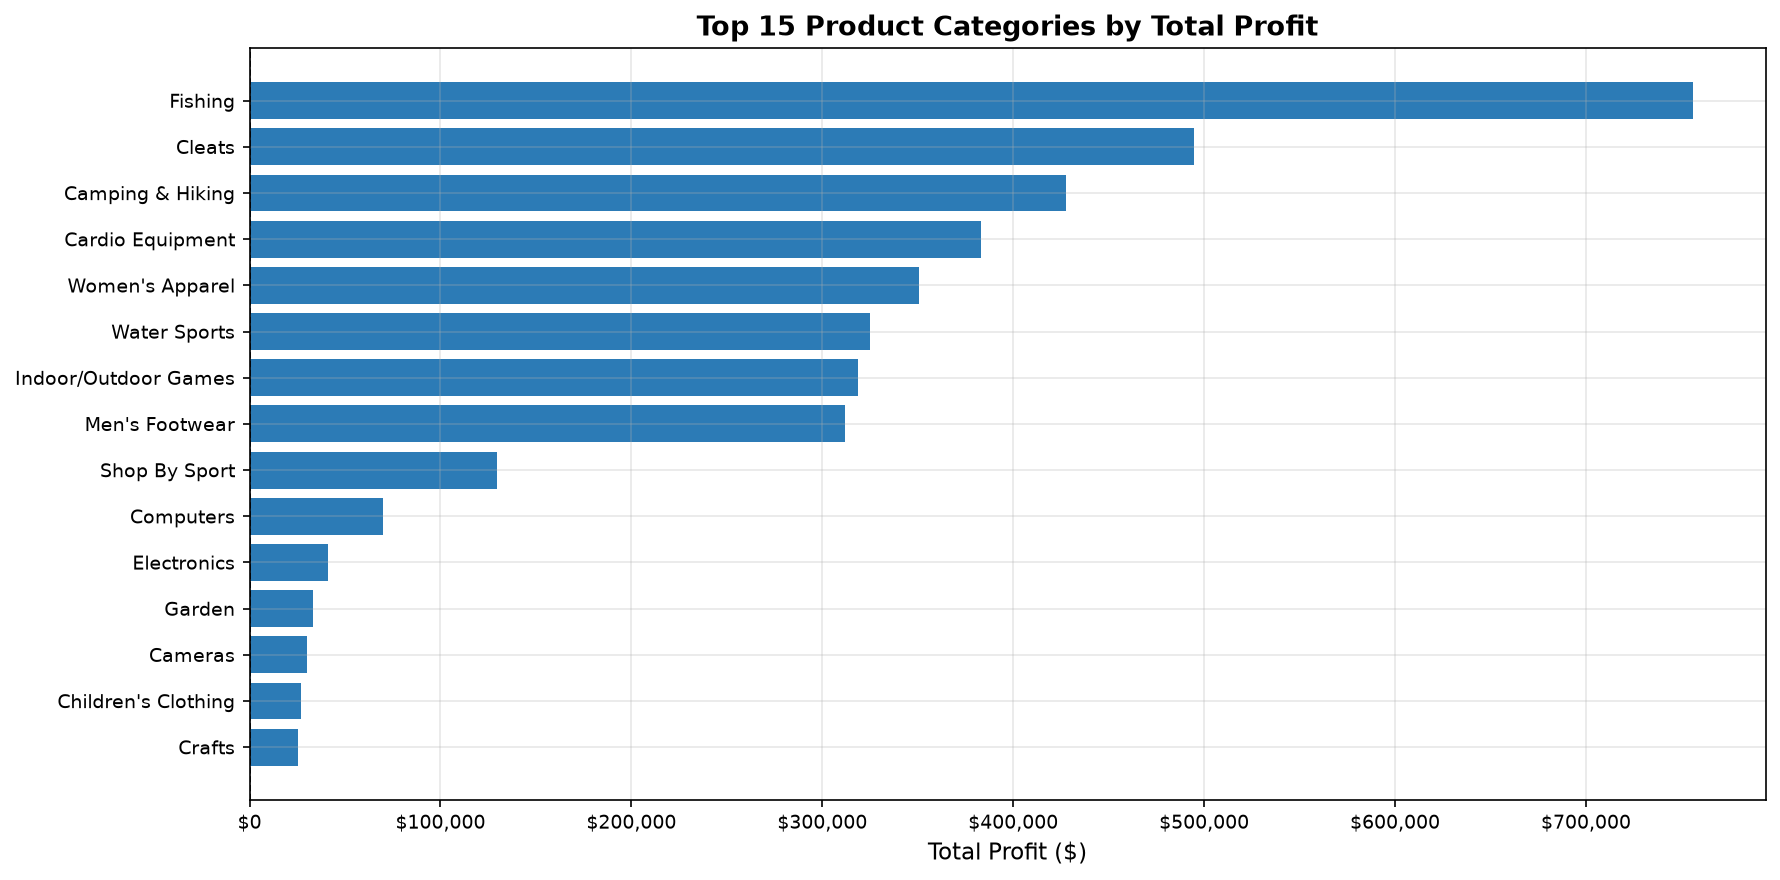

Category Name
Fishing                 756220.767190
Cleats                  494636.919791
Camping & Hiking        427455.568106
Cardio Equipment        383011.098485
Women's Apparel         350421.029567
Water Sports            325146.960038
Indoor/Outdoor Games    318451.430554
Men's Footwear          311902.820214
Shop By Sport           129813.960315
Computers                69656.810171
Electronics              40891.379918
Garden                   33443.010106
Cameras                  30289.799946
Children's Clothing      27178.099597
Crafts                   25531.170060


In [27]:
# --- Profit by Category ---
profit_cat = df.groupby('Category Name')['Order Profit Per Order'].sum().sort_values(ascending=False).head(15)

colors_cat = ['#d73027' if v < 0 else ACCENT for v in profit_cat.values[::-1]]
fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(profit_cat.index[::-1], profit_cat.values[::-1], color=colors_cat)
ax.set_xlabel('Total Profit ($)')
ax.set_title('Top 15 Product Categories by Total Profit', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
save_fig('profit_by_category.png')
plt.show()
print(profit_cat.to_string())

  Saved → analysis_images\profit_trend.png


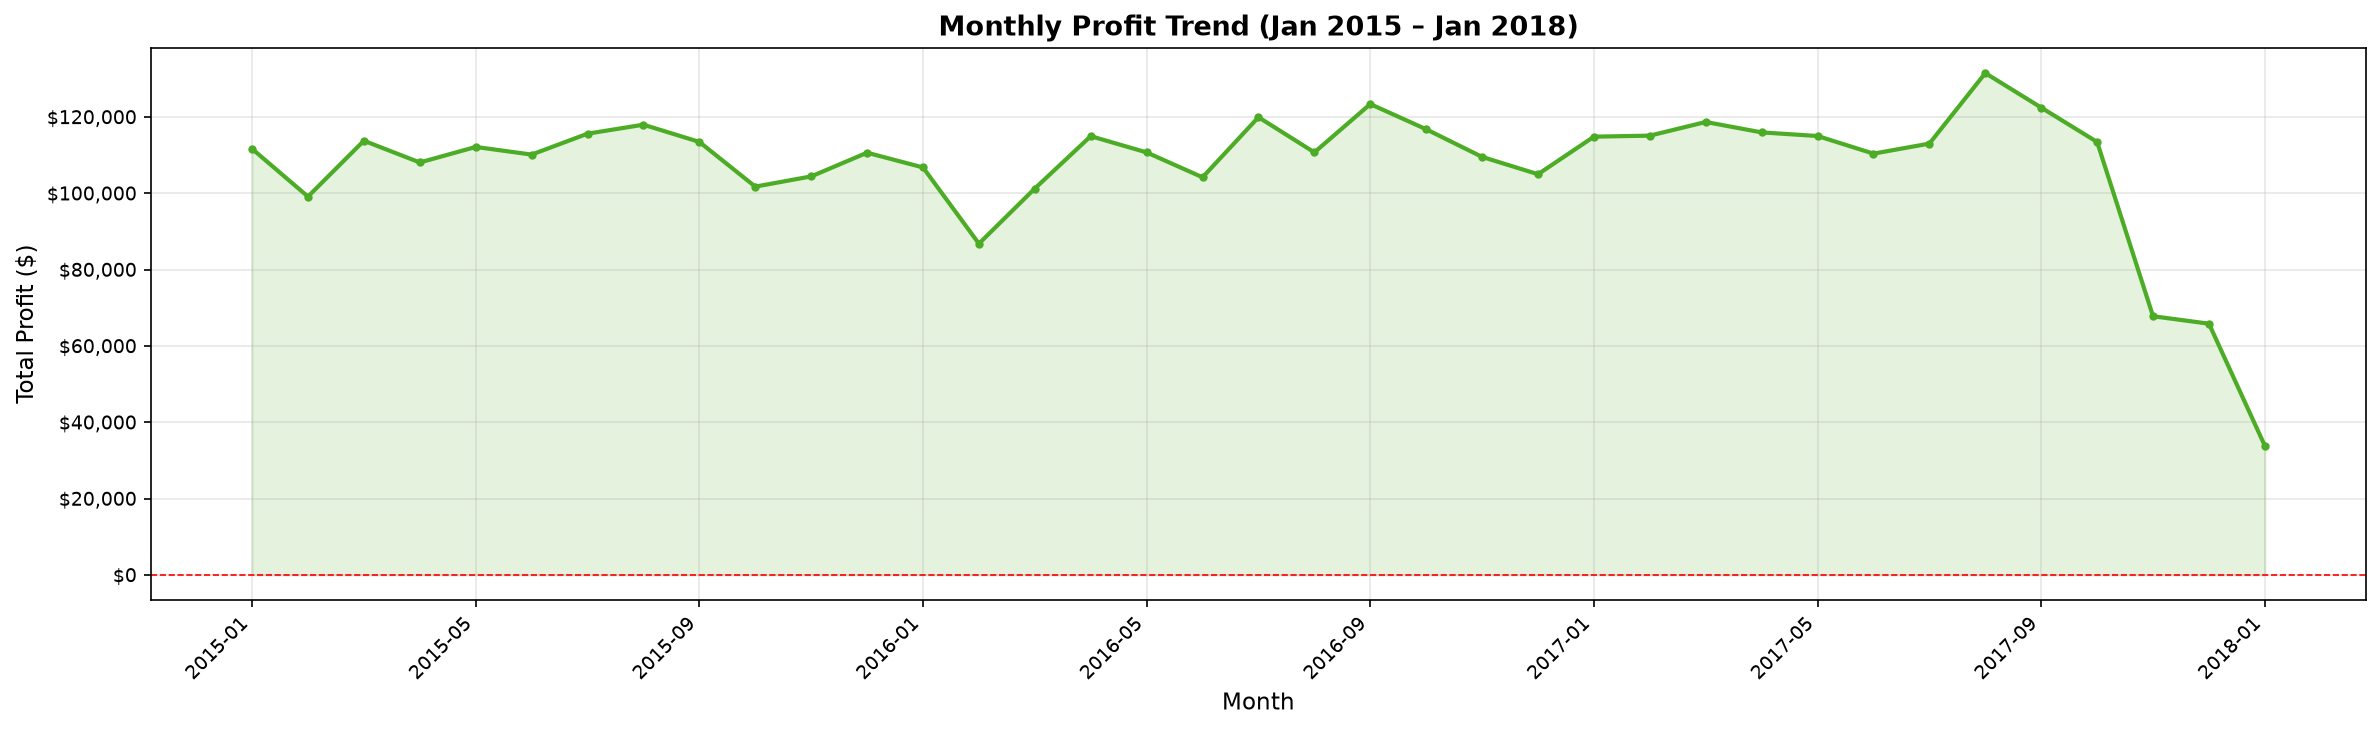

In [28]:
# --- Monthly Profit Trend ---
monthly_profit = df.groupby('order_yearmonth')['Order Profit Per Order'].sum().reset_index()
monthly_profit['order_yearmonth'] = monthly_profit['order_yearmonth'].astype(str)

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(monthly_profit['order_yearmonth'], monthly_profit['Order Profit Per Order'],
        color='#4dac26', linewidth=2, marker='o', markersize=3)
ax.fill_between(monthly_profit['order_yearmonth'], monthly_profit['Order Profit Per Order'],
                alpha=0.15, color='#4dac26')
ax.axhline(0, color='red', linestyle='--', linewidth=0.8)
ax.set_xlabel('Month')
ax.set_ylabel('Total Profit ($)')
ax.set_title('Monthly Profit Trend (Jan 2015 – Jan 2018)', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
tick_positions = list(range(0, len(monthly_profit), 4))
ax.set_xticks(tick_positions)
ax.set_xticklabels([monthly_profit['order_yearmonth'].iloc[i] for i in tick_positions], rotation=45, ha='right')
plt.tight_layout()
save_fig('profit_trend.png')
plt.show()

  Saved → analysis_images\profit_by_region.png


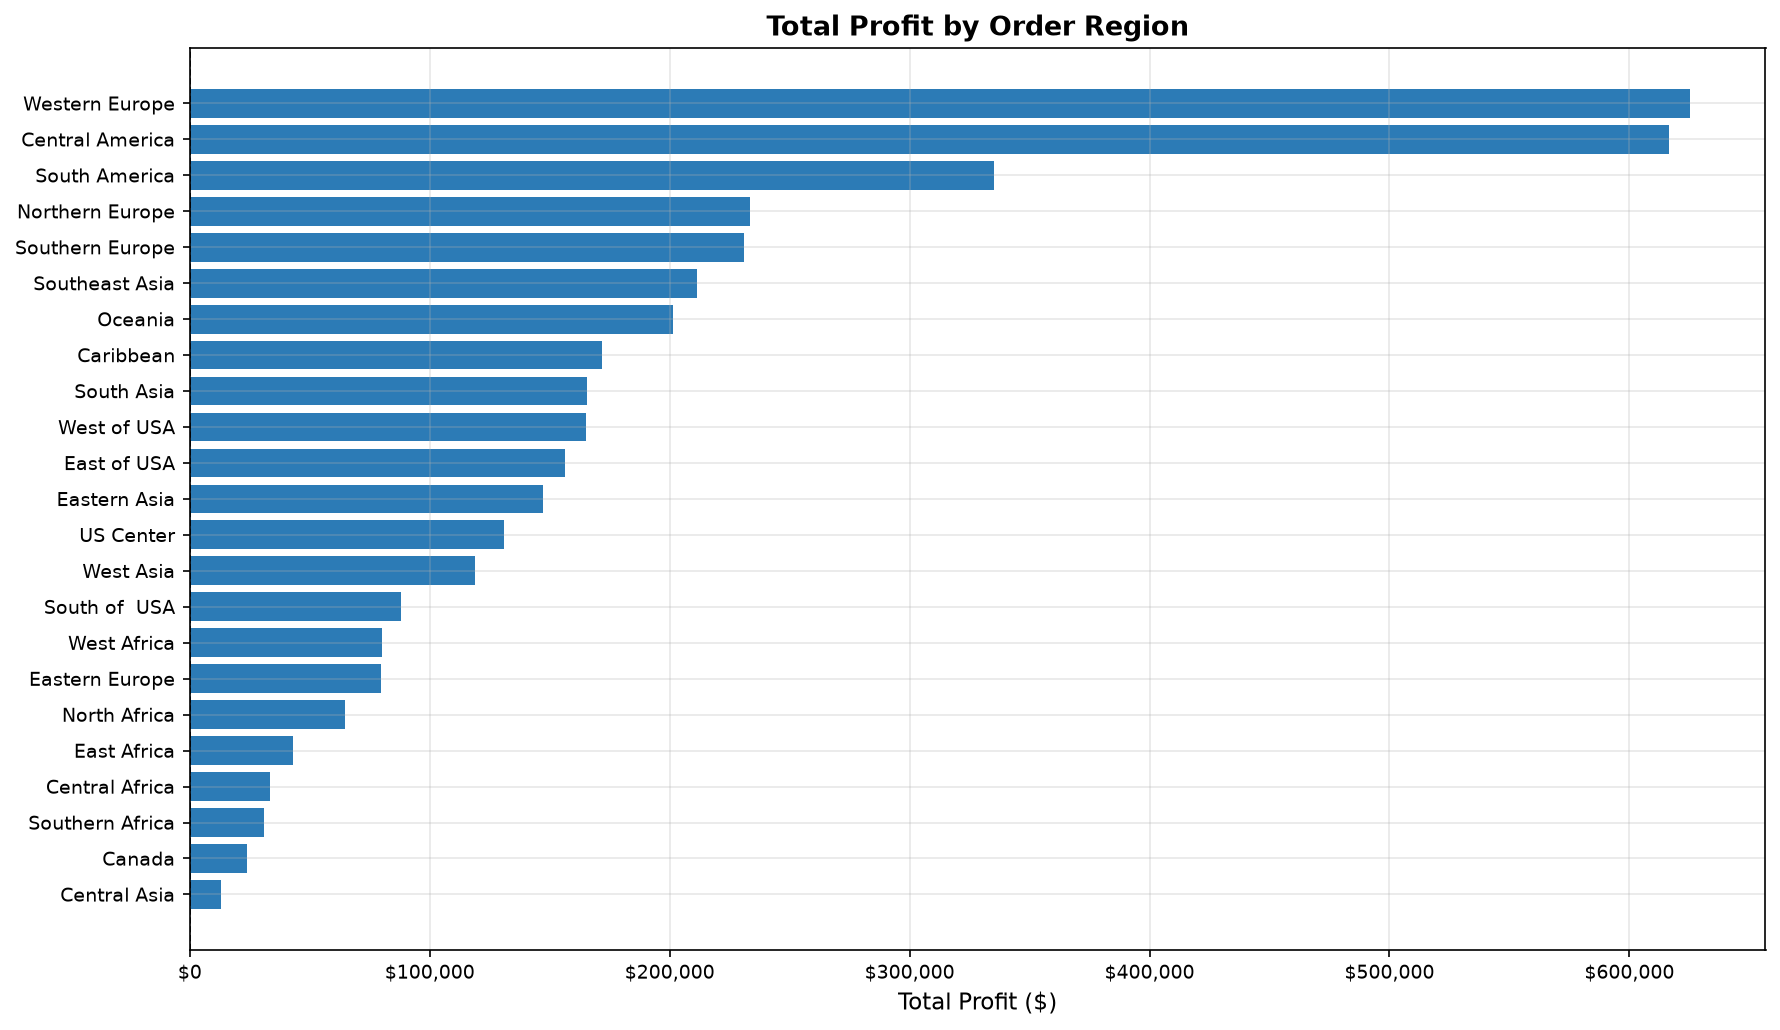

Order Region
Western Europe     625446.080548
Central America    616341.570651
South America      335154.400817
Northern Europe    233450.600647
Southern Europe    230829.229883
Southeast Asia     211342.819786
Oceania            201478.020484
Caribbean          171825.640024
South Asia         165703.900124
West of USA        164940.660455
East of USA        156263.300194
Eastern Asia       147368.010614
US Center          131094.229875
West Asia          118815.410047
South of  USA       88114.879898
West Africa         80030.270031
Eastern Europe      79717.049920
North Africa        64599.860009
East Africa         43167.729927
Central Africa      33447.269960
Southern Africa     30826.050146
Canada              23900.709960
Central Asia        13045.280051


In [29]:
# --- Profit by Region ---
profit_region = df.groupby('Order Region')['Order Profit Per Order'].sum().sort_values(ascending=False)
colors_reg = ['#d73027' if v < 0 else ACCENT for v in profit_region.values[::-1]]

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(profit_region.index[::-1], profit_region.values[::-1], color=colors_reg)
ax.set_xlabel('Total Profit ($)')
ax.set_title('Total Profit by Order Region', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
save_fig('profit_by_region.png')
plt.show()
print(profit_region.to_string())

  Saved → analysis_images\profit_by_market.png


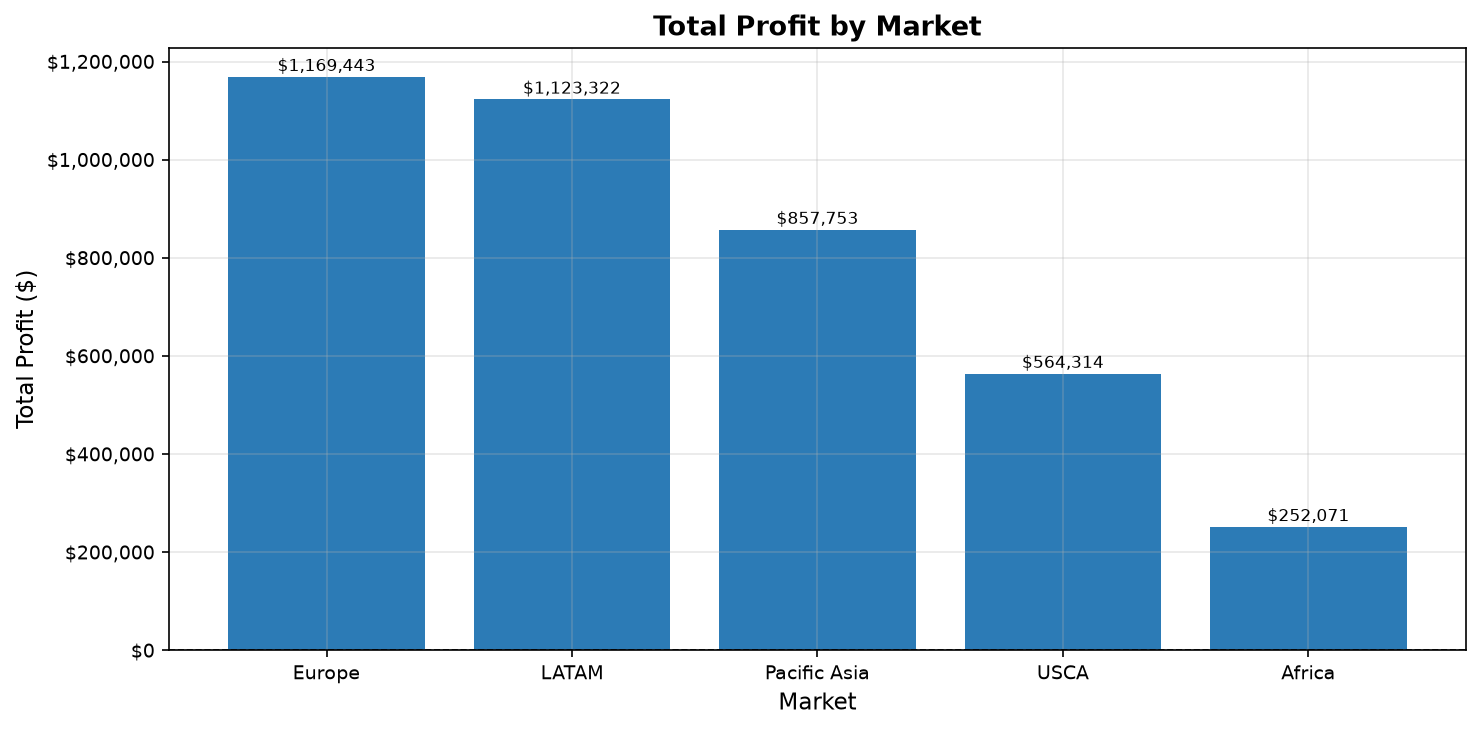

Market
Europe          1.169443e+06
LATAM           1.123322e+06
Pacific Asia    8.577534e+05
USCA            5.643138e+05
Africa          2.520712e+05


In [30]:
# --- Profit by Market ---
profit_market = df.groupby('Market')['Order Profit Per Order'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors_mkt = ['#d73027' if v < 0 else ACCENT for v in profit_market.values]
ax.bar(profit_market.index, profit_market.values, color=colors_mkt)
ax.set_xlabel('Market')
ax.set_ylabel('Total Profit ($)')
ax.set_title('Total Profit by Market', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
for i, (idx, val) in enumerate(profit_market.items()):
    ax.text(i, val + (profit_market.max()*0.01), f'${val:,.0f}', ha='center', fontsize=8)
plt.tight_layout()
save_fig('profit_by_market.png')
plt.show()
print(profit_market.to_string())

## 17. Customer Analysis

,Total_Sales,Total_Profit,Order_Count,Avg_Order_Val,Profit_Margin_%
Customer Segment,,,,,
Consumer,19095790.16,2073487.67,93504,204.22,10.86
Corporate,11168406.84,1202574.96,54789,203.84,10.77
Home Office,6520538.02,690840.34,32226,202.34,10.59


  Saved → analysis_images\customer_segment_sales.png


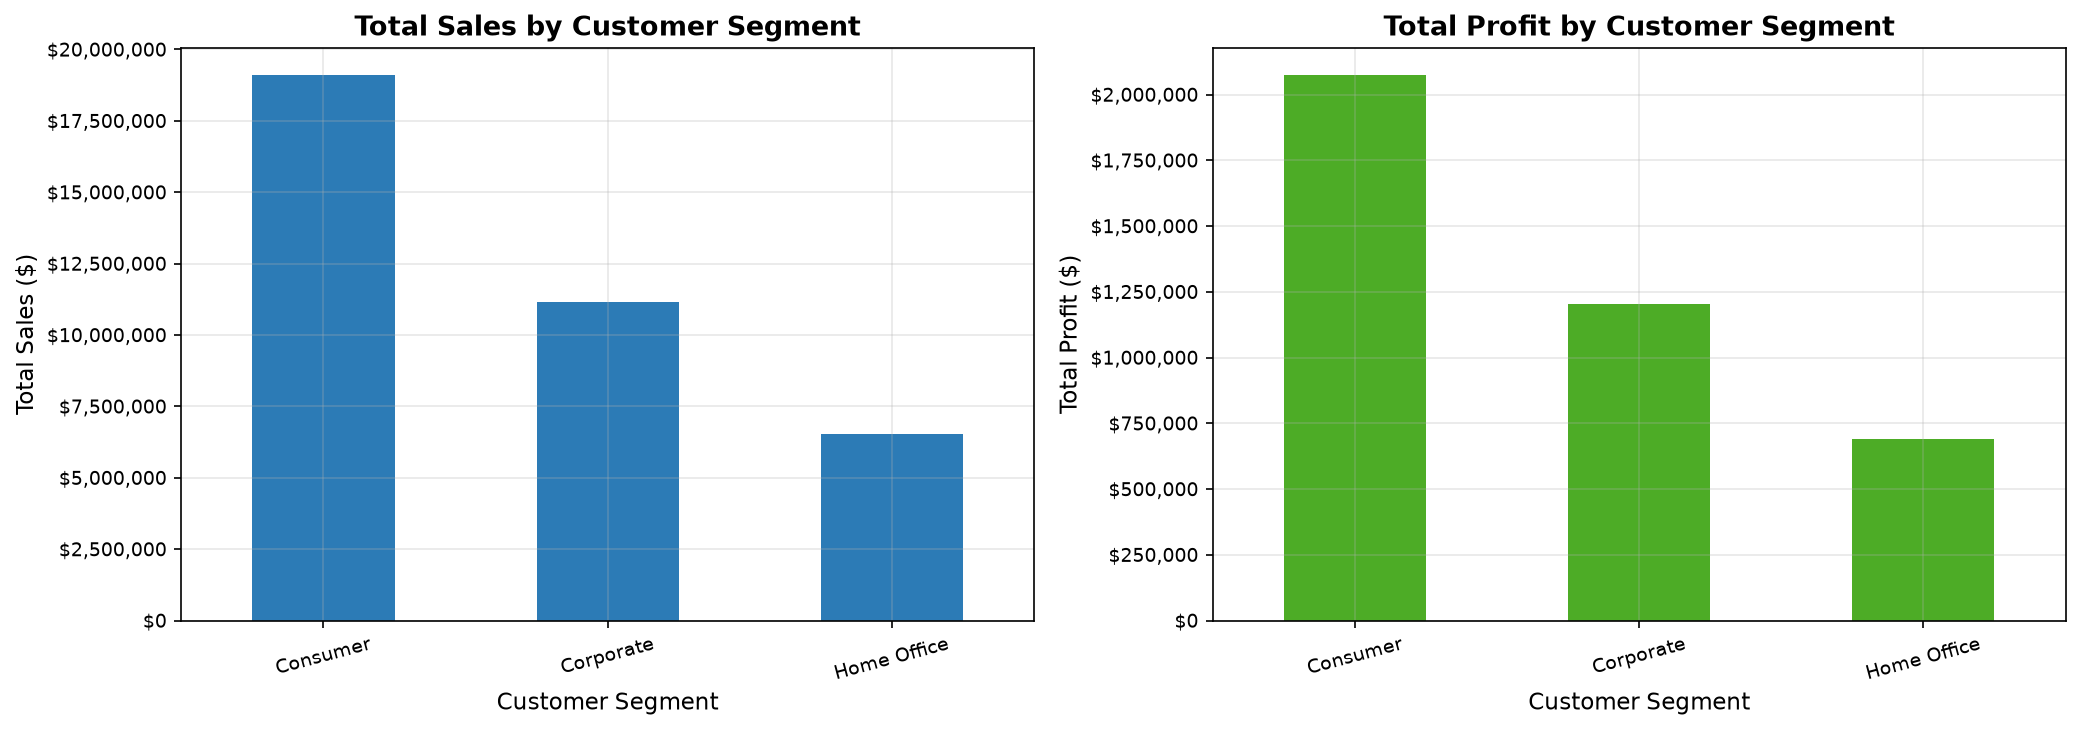

In [31]:
# --- Sales and Profit by Customer Segment ---
seg_perf = df.groupby('Customer Segment').agg(
    Total_Sales   = ('Sales', 'sum'),
    Total_Profit  = ('Order Profit Per Order', 'sum'),
    Order_Count   = ('Order Id', 'count'),
    Avg_Order_Val = ('Sales', 'mean')
).round(2)
seg_perf['Profit_Margin_%'] = (seg_perf['Total_Profit'] / seg_perf['Total_Sales'] * 100).round(2)
display(seg_perf)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
seg_perf['Total_Sales'].plot(kind='bar', ax=axes[0], color=ACCENT)
axes[0].set_title('Total Sales by Customer Segment', fontweight='bold')
axes[0].set_ylabel('Total Sales ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].tick_params(axis='x', rotation=15)

seg_perf['Total_Profit'].plot(kind='bar', ax=axes[1], color='#4dac26')
axes[1].set_title('Total Profit by Customer Segment', fontweight='bold')
axes[1].set_ylabel('Total Profit ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].tick_params(axis='x', rotation=15)
plt.tight_layout()
save_fig('customer_segment_sales.png')
plt.show()

  Saved → analysis_images\customer_segment_profit.png


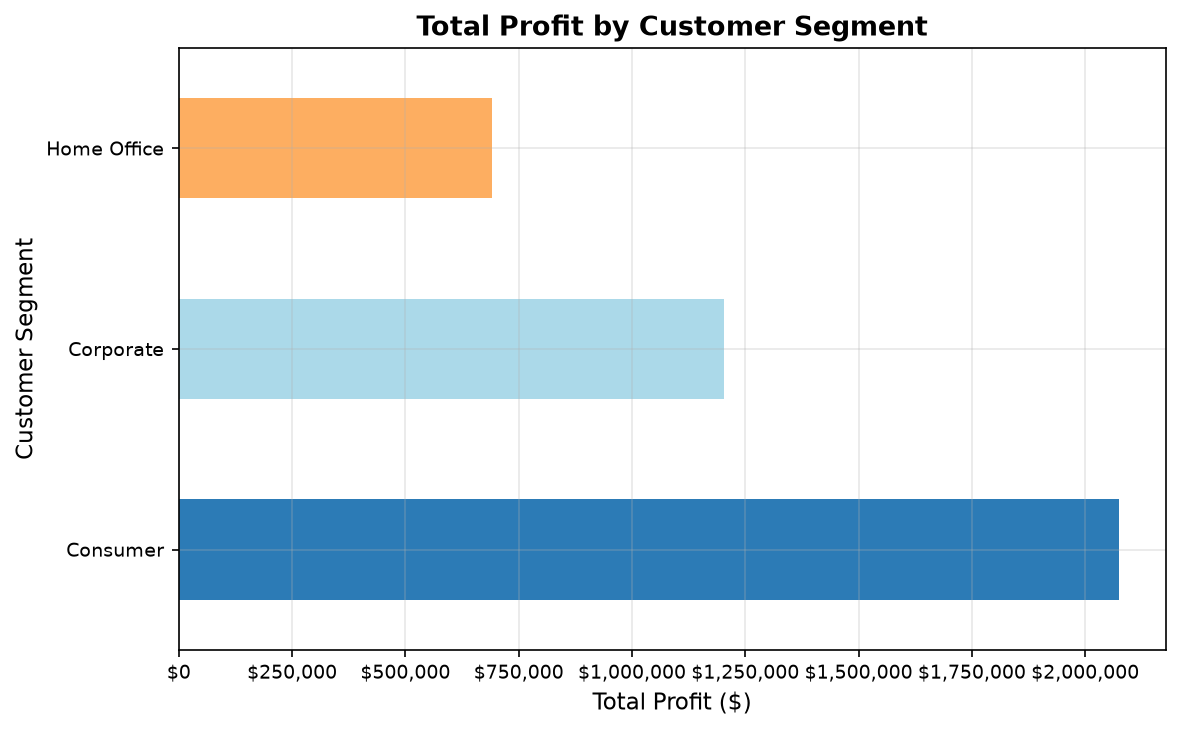

In [32]:
# Customer Segment Profit breakdown
fig, ax = plt.subplots(figsize=(8, 5))
seg_perf['Total_Profit'].plot(kind='barh', ax=ax, color=['#2c7bb6','#abd9e9','#fdae61'])
ax.set_xlabel('Total Profit ($)')
ax.set_title('Total Profit by Customer Segment', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
save_fig('customer_segment_profit.png')
plt.show()

## 18. Product Analysis

  Saved → analysis_images\top_products.png


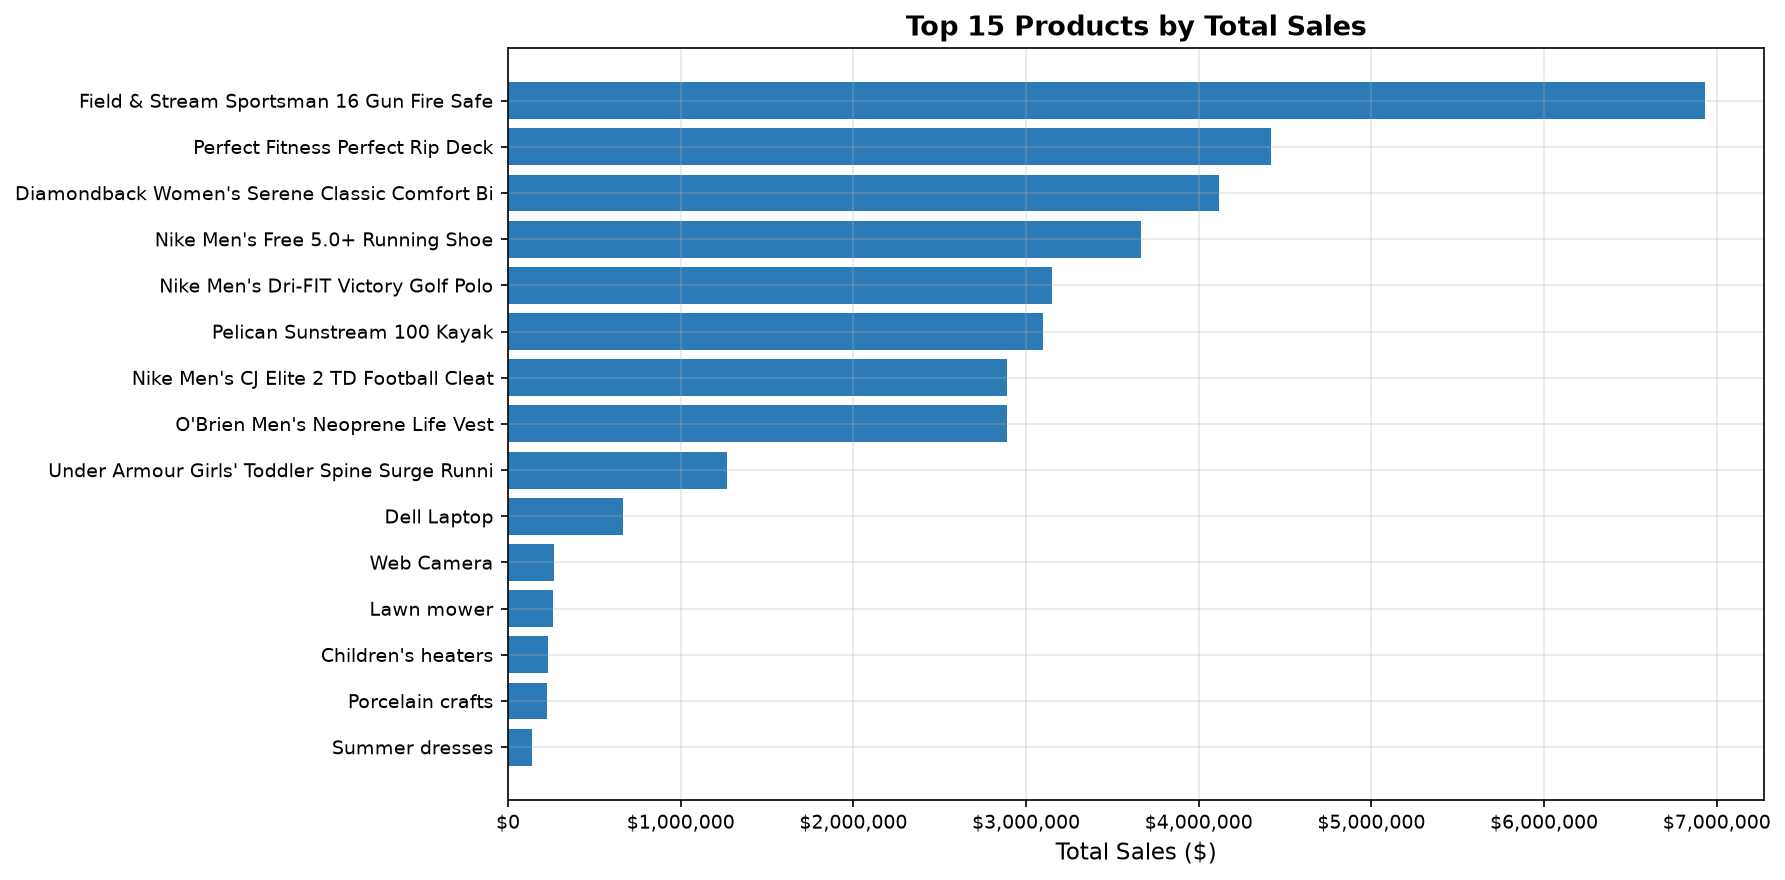

In [33]:
# --- Top Products by Sales ---
top_products_sales = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top_products_sales.index[::-1], top_products_sales.values[::-1], color=ACCENT)
ax.set_xlabel('Total Sales ($)')
ax.set_title('Top 15 Products by Total Sales', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
save_fig('top_products.png')
plt.show()

  Saved → analysis_images\top_profitable_products.png


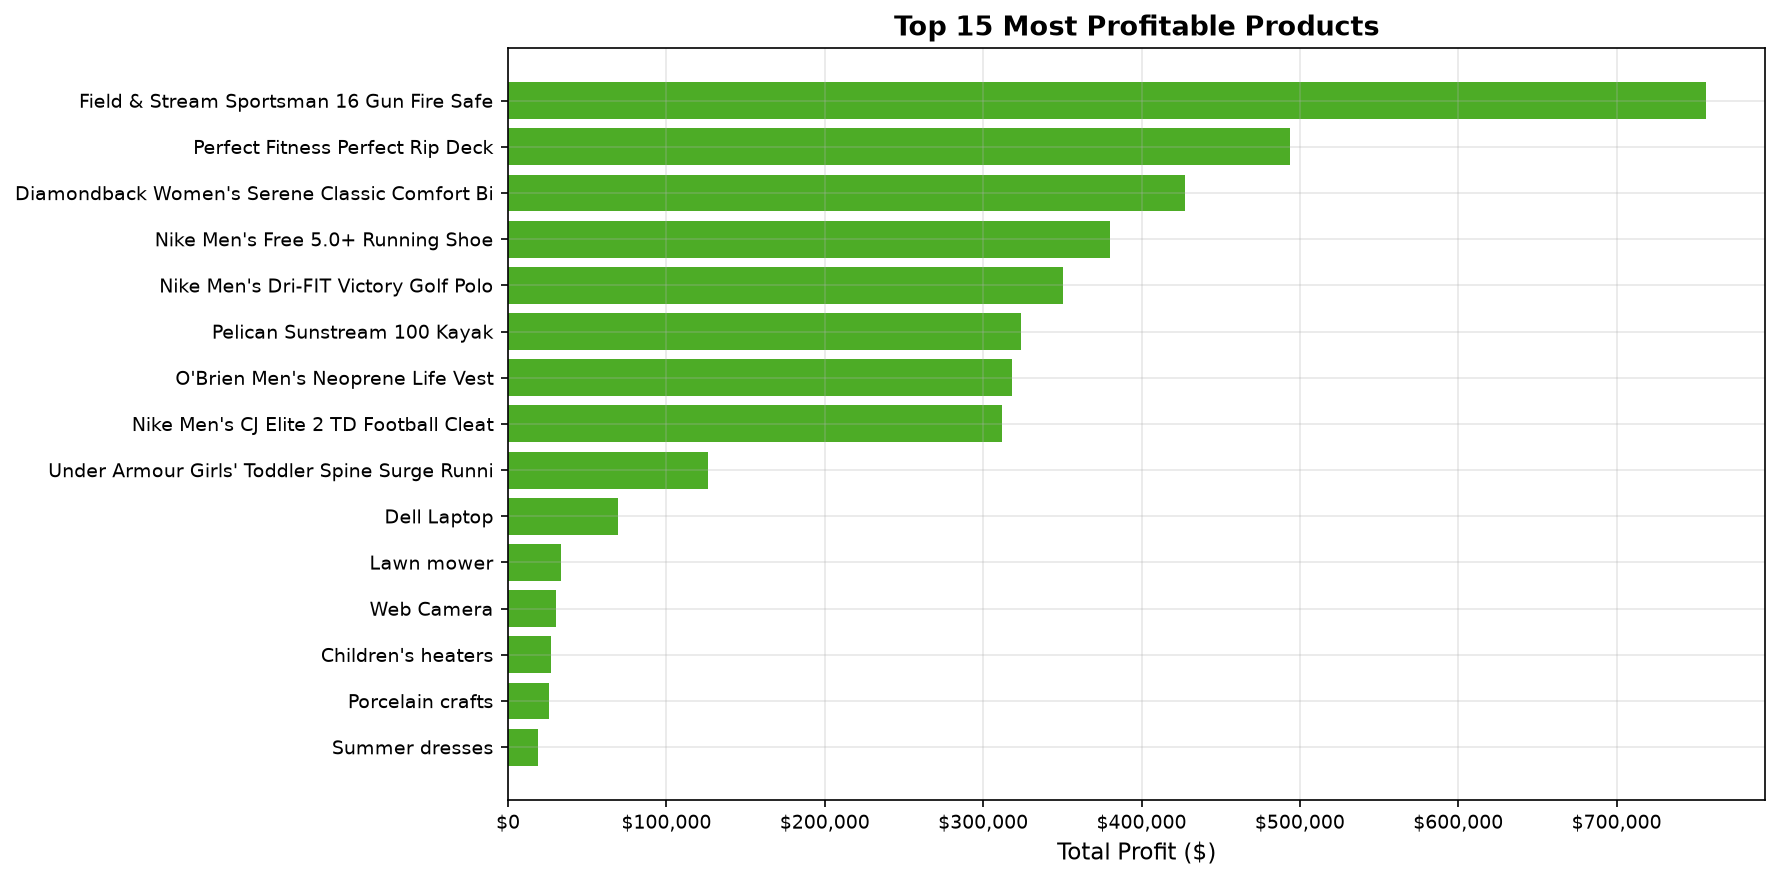

In [34]:
# --- Top Products by Profit ---
top_products_profit = df.groupby('Product Name')['Order Profit Per Order'].sum().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top_products_profit.index[::-1], top_products_profit.values[::-1], color='#4dac26')
ax.set_xlabel('Total Profit ($)')
ax.set_title('Top 15 Most Profitable Products', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
save_fig('top_profitable_products.png')
plt.show()

  Saved → analysis_images\low_profit_products.png


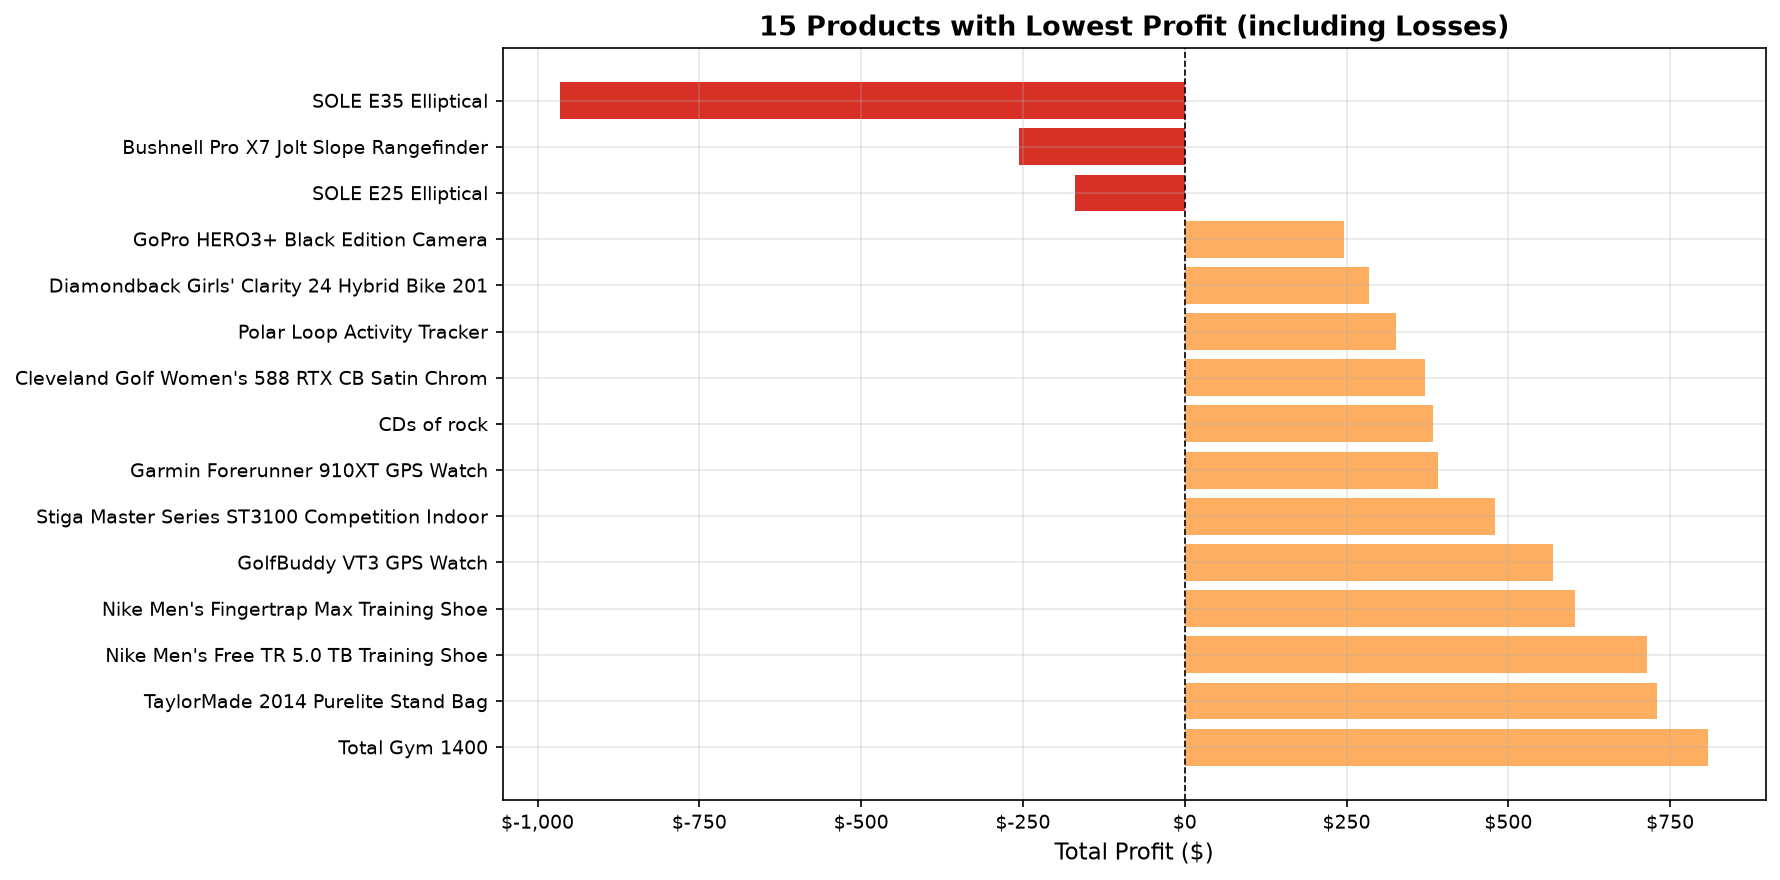

Products with largest losses:
Product Name
SOLE E35 Elliptical                             -965.119968
Bushnell Pro X7 Jolt Slope Rangefinder          -255.950003
SOLE E25 Elliptical                             -169.559997
GoPro HERO3+ Black Edition Camera                245.630051
Diamondback Girls' Clarity 24 Hybrid Bike 201    284.420003
Polar Loop Activity Tracker                      326.200001
Cleveland Golf Women's 588 RTX CB Satin Chrom    370.610006
CDs of rock                                      383.850000
Garmin Forerunner 910XT GPS Watch                391.129990
Stiga Master Series ST3100 Competition Indoor    479.280016
GolfBuddy VT3 GPS Watch                          569.020010
Nike Men's Fingertrap Max Training Shoe          602.379973
Nike Men's Free TR 5.0 TB Training Shoe          714.429980
TaylorMade 2014 Purelite Stand Bag               730.180011
Total Gym 1400                                   808.620008


In [35]:
# --- Low/Negative Profit Products ---
prod_profit = df.groupby('Product Name')['Order Profit Per Order'].sum().sort_values()
low_profit = prod_profit.head(15)  # most negative first

colors_lp = ['#d73027' if v < 0 else '#fdae61' for v in low_profit.values[::-1]]
fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(low_profit.index[::-1], low_profit.values[::-1], color=colors_lp)
ax.set_xlabel('Total Profit ($)')
ax.set_title('15 Products with Lowest Profit (including Losses)', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
save_fig('low_profit_products.png')
plt.show()
print('Products with largest losses:')
print(low_profit.to_string())

## 19. Regional Analysis

In [36]:
regional_perf = df.groupby('Order Region').agg(
    Total_Sales  = ('Sales', 'sum'),
    Total_Profit = ('Order Profit Per Order', 'sum'),
    Order_Count  = ('Order Id', 'count'),
    Late_Rate    = ('Late_delivery_risk', 'mean')
).round(2)
regional_perf['Profit_Margin_%'] = (regional_perf['Total_Profit'] / regional_perf['Total_Sales'] * 100).round(2)
regional_perf['Late_Rate_%'] = (regional_perf['Late_Rate'] * 100).round(1)
display(regional_perf.sort_values('Total_Sales', ascending=False))

,Total_Sales,Total_Profit,Order_Count,Late_Rate,Profit_Margin_%,Late_Rate_%
Order Region,,,,,,
Western Europe,5894380.77,625446.08,27109,0.56,10.61,56.0
Central America,5665712.10,616341.57,28341,0.55,10.88,55.0
South America,2960881.41,335154.40,14935,0.54,11.32,54.0
Northern Europe,2155830.65,233450.60,9792,0.54,10.83,54.0
Southern Europe,2047918.82,230829.23,9431,0.54,11.27,54.0
Oceania,2016654.20,201478.02,10148,0.54,9.99,54.0
Southeast Asia,1932495.57,211342.82,9539,0.56,10.94,56.0
Caribbean,1651019.33,171825.64,8318,0.53,10.41,53.0
West of USA,1571415.96,164940.66,7993,0.54,10.50,54.0


## 20. Market Analysis

In [37]:
market_perf = df.groupby('Market').agg(
    Total_Sales  = ('Sales', 'sum'),
    Total_Profit = ('Order Profit Per Order', 'sum'),
    Order_Count  = ('Order Id', 'count'),
    Late_Rate    = ('Late_delivery_risk', 'mean'),
    Avg_Discount = ('Order Item Discount Rate', 'mean')
).round(2)
market_perf['Profit_Margin_%'] = (market_perf['Total_Profit'] / market_perf['Total_Sales'] * 100).round(2)
market_perf['Late_Rate_%'] = (market_perf['Late_Rate'] * 100).round(1)
market_perf['Avg_Discount_%'] = (market_perf['Avg_Discount'] * 100).round(1)
display(market_perf.sort_values('Total_Sales', ascending=False))

,Total_Sales,Total_Profit,Order_Count,Late_Rate,Avg_Discount,Profit_Margin_%,Late_Rate_%,Avg_Discount_%
Market,,,,,,,,
Europe,10872396.80,1169442.96,50252,0.55,0.1,10.76,55.0,10.0
LATAM,10277612.84,1123321.61,51594,0.54,0.1,10.93,54.0,10.0
Pacific Asia,8273743.74,857753.44,41260,0.55,0.1,10.37,55.0,10.0
USCA,5066528.71,564313.78,25799,0.55,0.1,11.14,55.0,10.0
Africa,2294452.93,252071.18,11614,0.55,0.1,10.99,55.0,10.0


## 21. Shipping Analysis

  Saved → analysis_images\shipping_mode_distribution.png


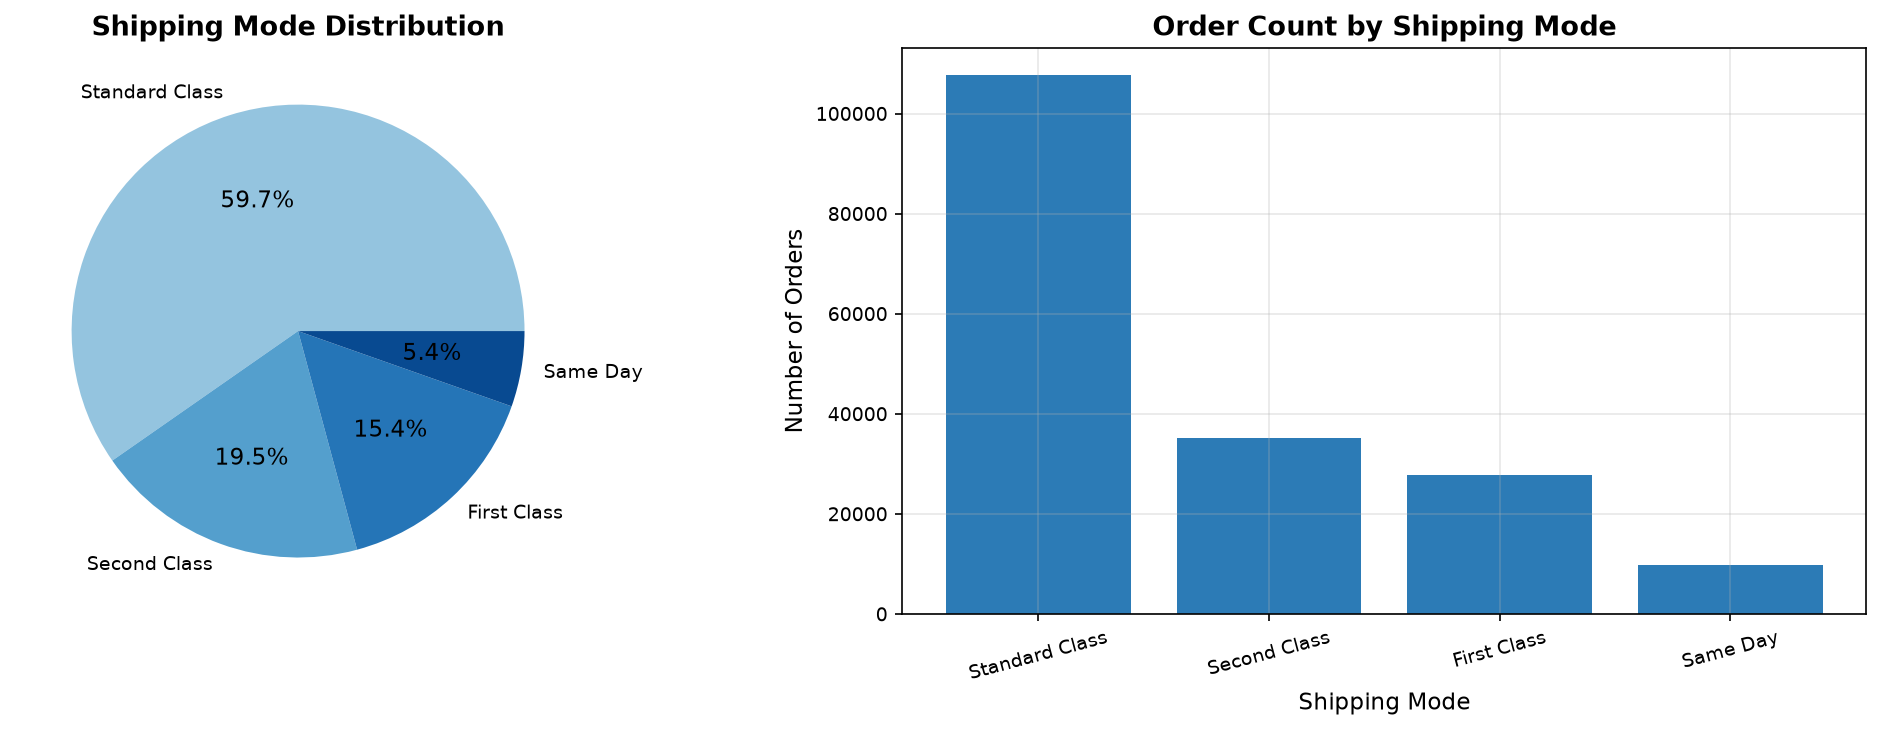

Shipping Mode
Standard Class    107752
Second Class       35216
First Class        27814
Same Day            9737


In [38]:
# --- Shipping Mode Distribution ---
ship_dist = df['Shipping Mode'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].pie(ship_dist.values, labels=ship_dist.index, autopct='%1.1f%%',
            colors=plt.cm.Blues(np.linspace(0.4, 0.9, len(ship_dist))))
axes[0].set_title('Shipping Mode Distribution', fontweight='bold')

axes[1].bar(ship_dist.index, ship_dist.values, color=ACCENT)
axes[1].set_xlabel('Shipping Mode')
axes[1].set_ylabel('Number of Orders')
axes[1].set_title('Order Count by Shipping Mode', fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)
plt.tight_layout()
save_fig('shipping_mode_distribution.png')
plt.show()
print(ship_dist.to_string())

,Late_Rate,Avg_Ship_Days,Avg_Sched_Days,Total_Profit,Order_Count,Late_Rate_%
Shipping Mode,,,,,,
First Class,0.95,2.00,1.0,643121.92,27814,95.0
Same Day,0.46,0.48,0.0,203018.43,9737,46.0
Second Class,0.77,3.99,2.0,750308.17,35216,77.0
Standard Class,0.38,4.00,4.0,2370454.45,107752,38.0


  Saved → analysis_images\shipping_mode_performance.png


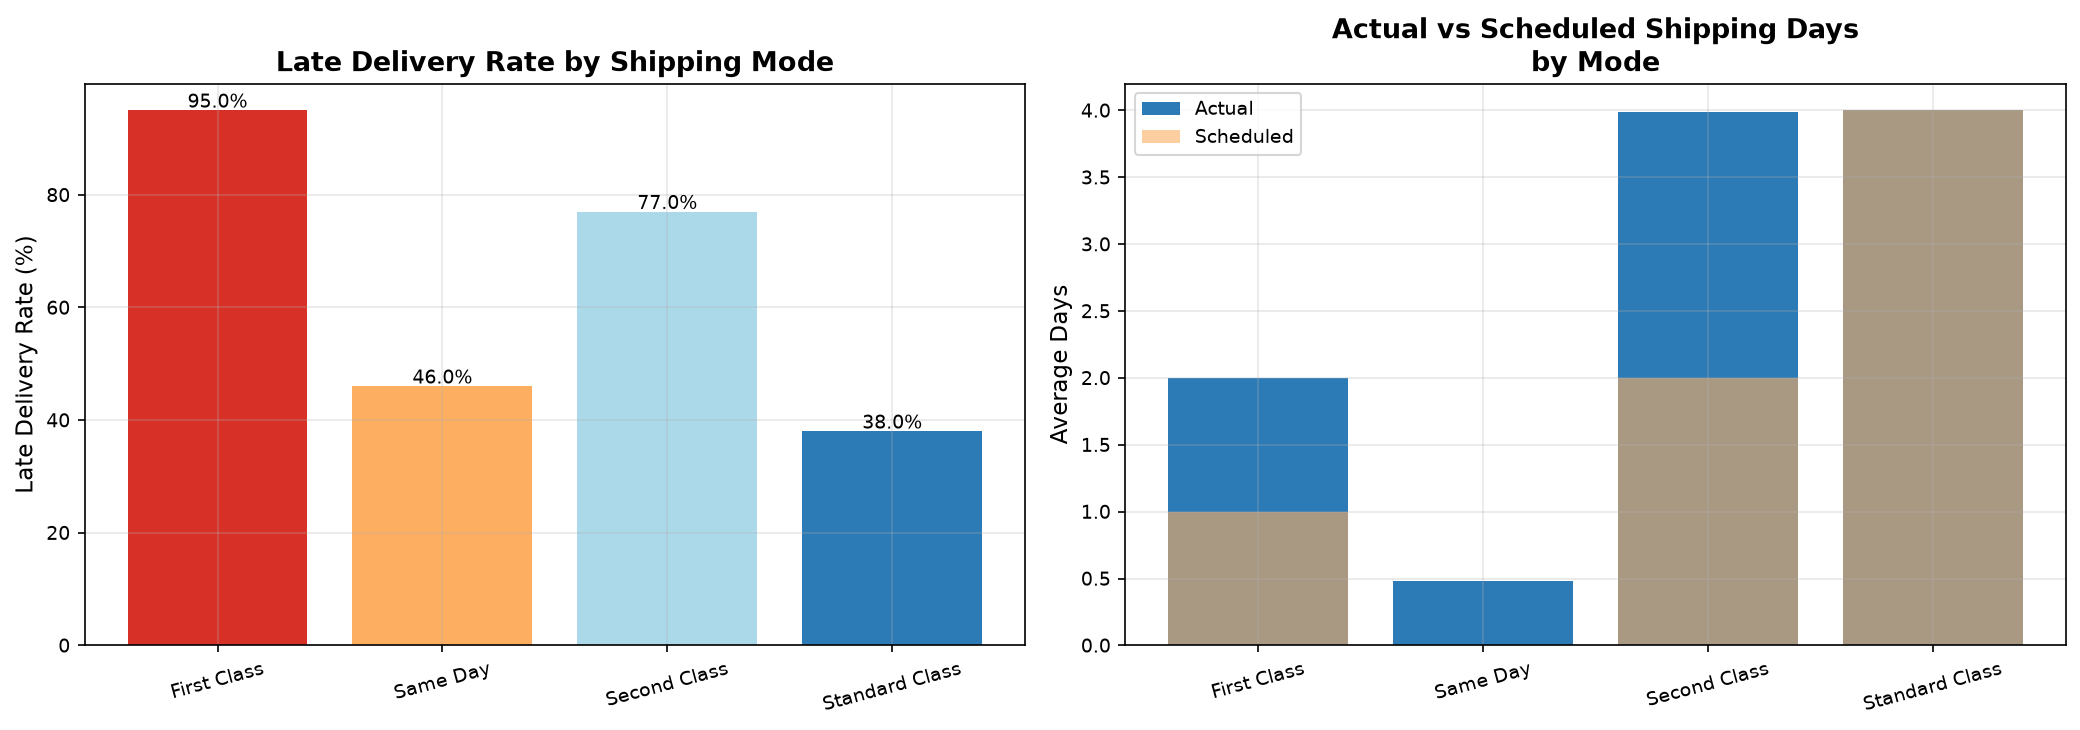

In [39]:
# --- Shipping Mode vs Delivery Performance ---
ship_perf = df.groupby('Shipping Mode').agg(
    Late_Rate      = ('Late_delivery_risk', 'mean'),
    Avg_Ship_Days  = ('Days for shipping (real)', 'mean'),
    Avg_Sched_Days = ('Days for shipment (scheduled)', 'mean'),
    Total_Profit   = ('Order Profit Per Order', 'sum'),
    Order_Count    = ('Order Id', 'count')
).round(2)
ship_perf['Late_Rate_%'] = (ship_perf['Late_Rate'] * 100).round(1)
display(ship_perf)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(ship_perf.index, ship_perf['Late_Rate_%'], color=['#d73027','#fdae61','#abd9e9','#2c7bb6'])
axes[0].set_ylabel('Late Delivery Rate (%)')
axes[0].set_title('Late Delivery Rate by Shipping Mode', fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)
for i, (idx, val) in enumerate(ship_perf['Late_Rate_%'].items()):
    axes[0].text(i, val + 0.5, f'{val}%', ha='center', fontsize=9)

axes[1].bar(ship_perf.index, ship_perf['Avg_Ship_Days'], color=ACCENT, label='Actual')
axes[1].bar(ship_perf.index, ship_perf['Avg_Sched_Days'], color='#fdae61', alpha=0.6, label='Scheduled')
axes[1].set_ylabel('Average Days')
axes[1].set_title('Actual vs Scheduled Shipping Days\nby Mode', fontweight='bold')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=15)
plt.tight_layout()
save_fig('shipping_mode_performance.png')
plt.show()

## 22. Delivery Performance Analysis

  Saved → analysis_images\late_delivery_distribution.png


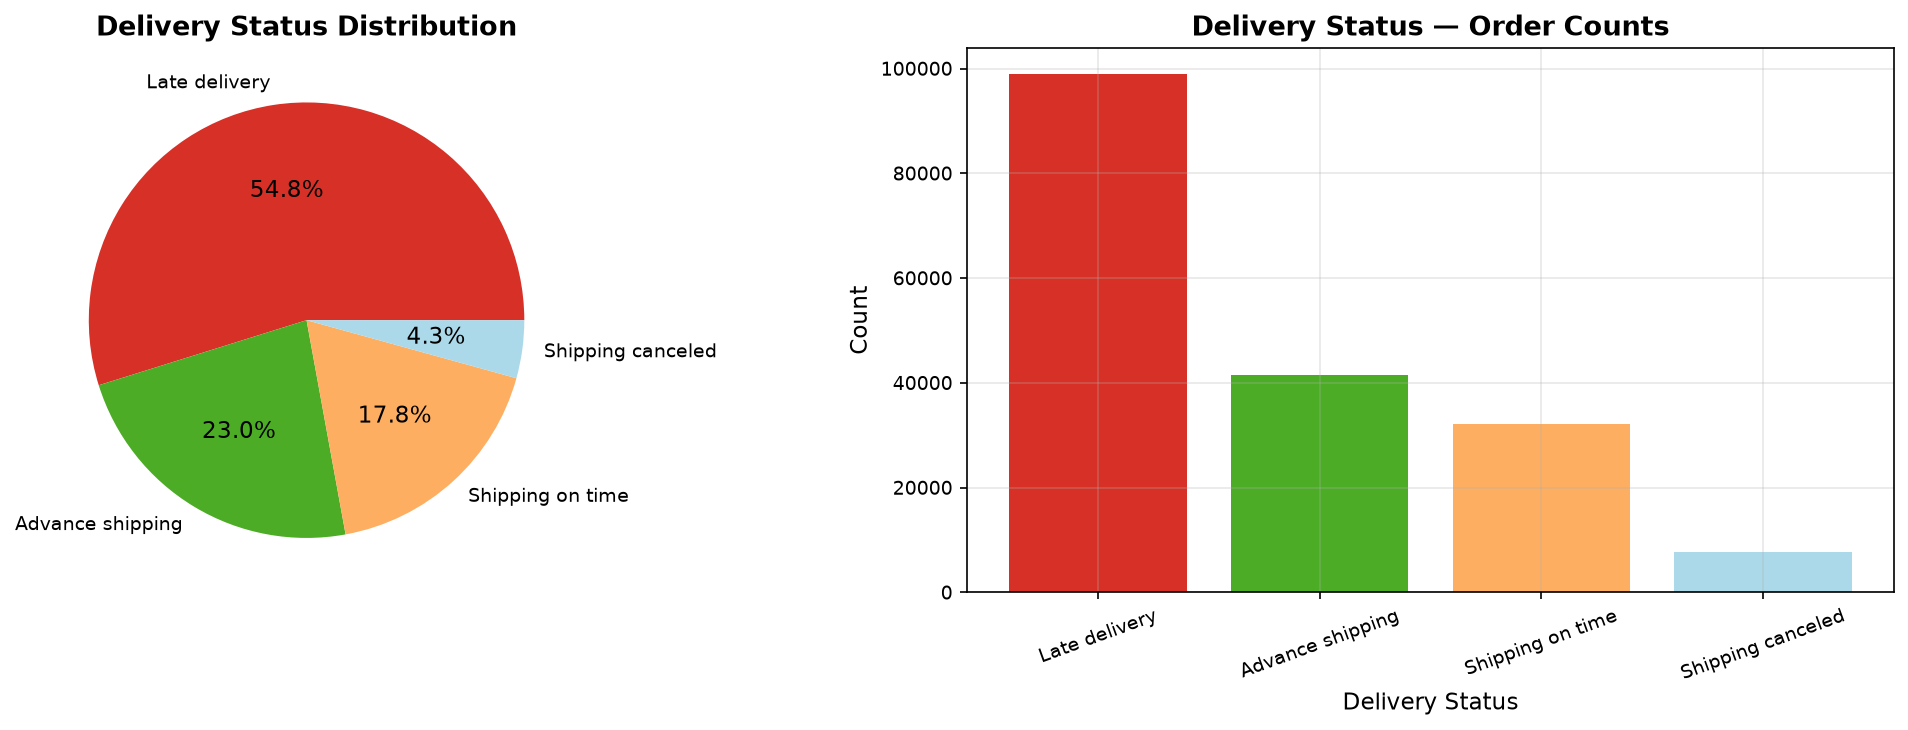

Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754

Late delivery rate: 54.8%


In [40]:
# --- Delivery Status Distribution ---
del_dist = df['Delivery Status'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].pie(del_dist.values, labels=del_dist.index, autopct='%1.1f%%',
            colors=['#d73027','#4dac26','#fdae61','#abd9e9'])
axes[0].set_title('Delivery Status Distribution', fontweight='bold')

axes[1].bar(del_dist.index, del_dist.values, color=['#d73027','#4dac26','#fdae61','#abd9e9'])
axes[1].set_xlabel('Delivery Status')
axes[1].set_ylabel('Count')
axes[1].set_title('Delivery Status — Order Counts', fontweight='bold')
axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout()
save_fig('late_delivery_distribution.png')
plt.show()
print(del_dist.to_string())
print(f'\nLate delivery rate: {del_dist.get("Late delivery",0)/del_dist.sum()*100:.1f}%')

  Saved → analysis_images\late_delivery_by_region.png


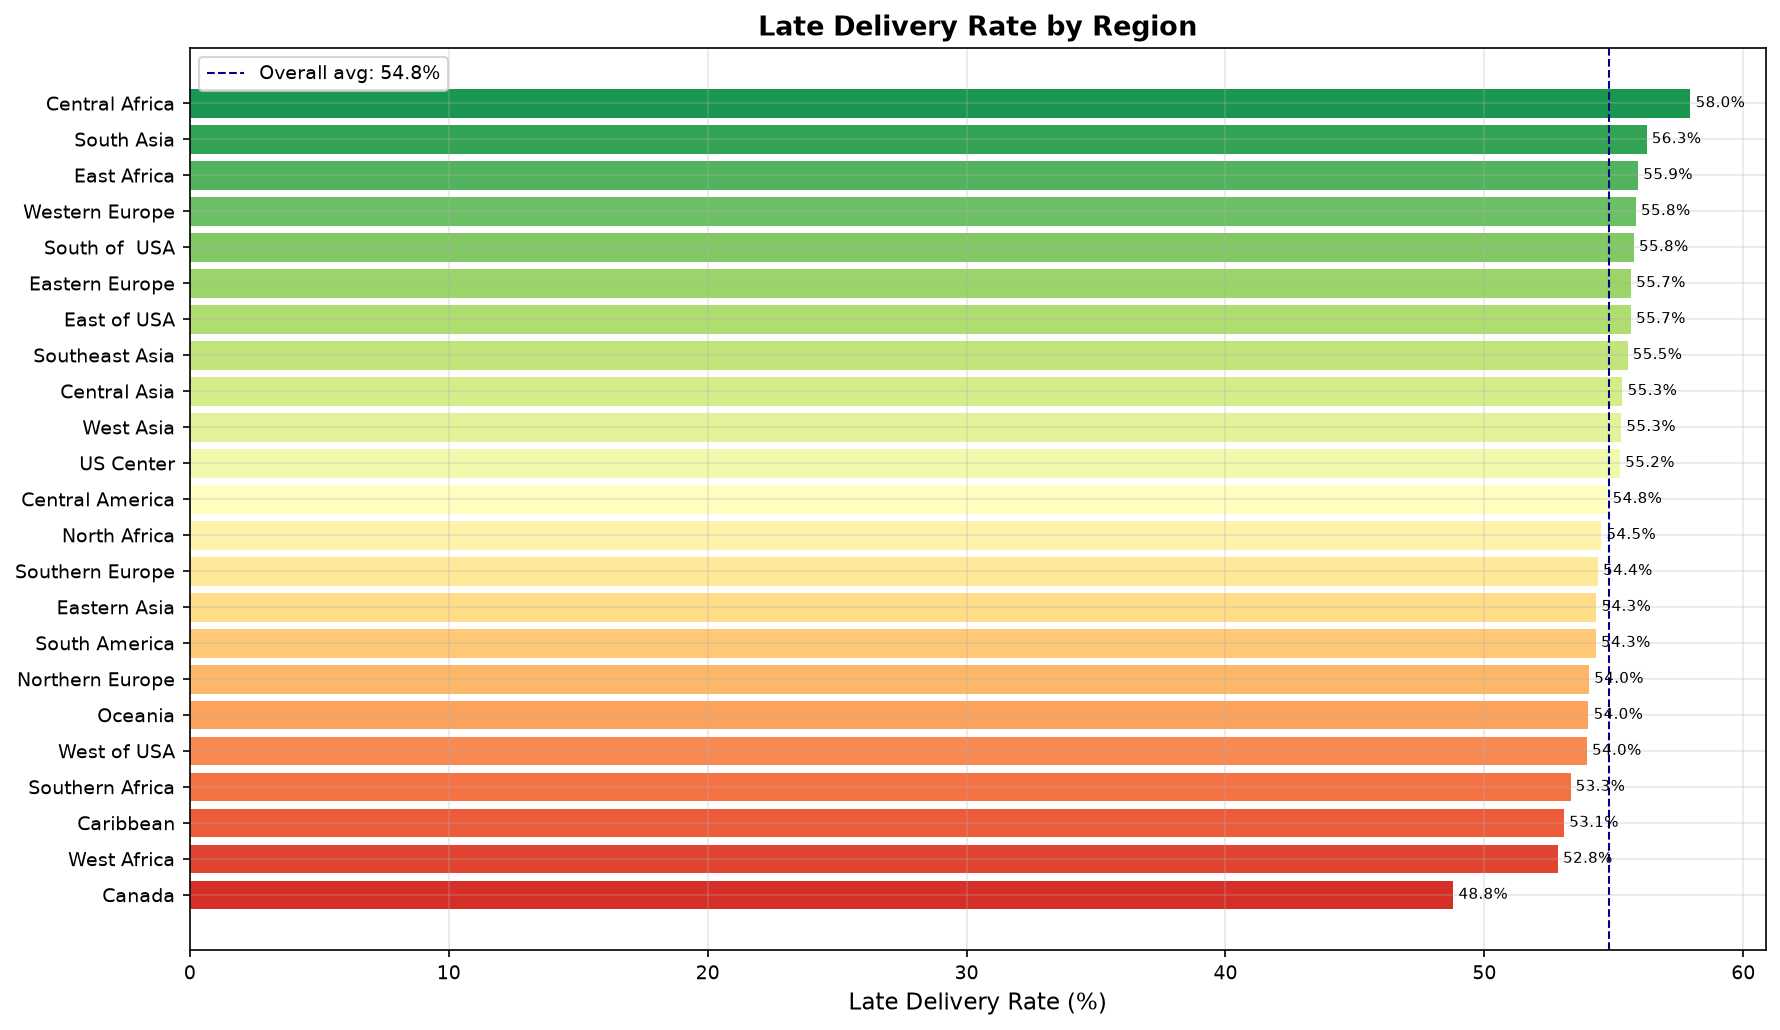

Order Region
Central Africa     57.960644
South Asia         56.266977
East Africa        55.939525
Western Europe     55.848611
South of  USA      55.772559
Eastern Europe     55.663265
East of USA        55.661605
Southeast Asia     55.529930
Central Asia       55.334539
West Asia          55.283741
US Center          55.240360
Central America    54.754596
North Africa       54.517327
Southern Europe    54.384477
Eastern Asia       54.326923
South America      54.308671
Northern Europe    54.044118
Oceania            54.020497
West of USA        53.959715
Southern Africa    53.327571
Caribbean          53.077663
West Africa        52.840909
Canada             48.800834


In [41]:
# --- Late Delivery by Region ---
late_region = df.groupby('Order Region')['Late_delivery_risk'].mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(12, 7))
colors_lr = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(late_region)))
ax.barh(late_region.index[::-1], late_region.values[::-1], color=colors_lr[::-1])
ax.set_xlabel('Late Delivery Rate (%)')
ax.set_title('Late Delivery Rate by Region', fontweight='bold')
ax.axvline(df['Late_delivery_risk'].mean()*100, color='navy', linestyle='--', linewidth=1, label=f'Overall avg: {df["Late_delivery_risk"].mean()*100:.1f}%')
ax.legend()
for i, (idx, val) in enumerate(late_region.items()):
    ax.text(val + 0.2, len(late_region)-1-i, f'{val:.1f}%', va='center', fontsize=7)
plt.tight_layout()
save_fig('late_delivery_by_region.png')
plt.show()
print(late_region.to_string())

  Saved → analysis_images\late_delivery_by_market.png


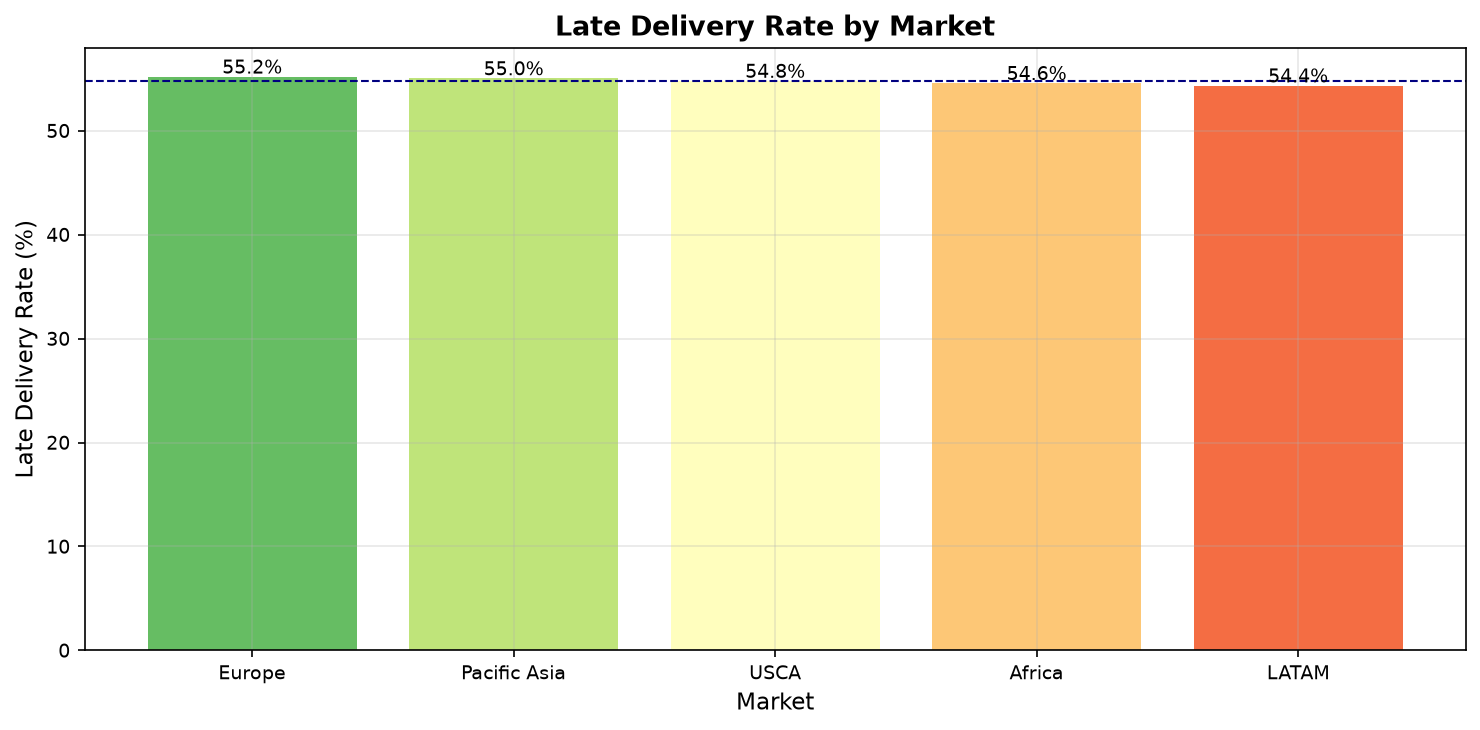

Market
Europe          55.207753
Pacific Asia    55.046049
USCA            54.800574
Africa          54.589289
LATAM           54.355158


In [42]:
# --- Late Delivery by Market ---
late_market = df.groupby('Market')['Late_delivery_risk'].mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(late_market.index, late_market.values, color=plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(late_market))))
ax.set_xlabel('Market')
ax.set_ylabel('Late Delivery Rate (%)')
ax.set_title('Late Delivery Rate by Market', fontweight='bold')
ax.axhline(df['Late_delivery_risk'].mean()*100, color='navy', linestyle='--', linewidth=1)
for bar, val in zip(bars, late_market.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.3, f'{val:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
save_fig('late_delivery_by_market.png')
plt.show()
print(late_market.to_string())

## 23. Late Delivery Risk Analysis

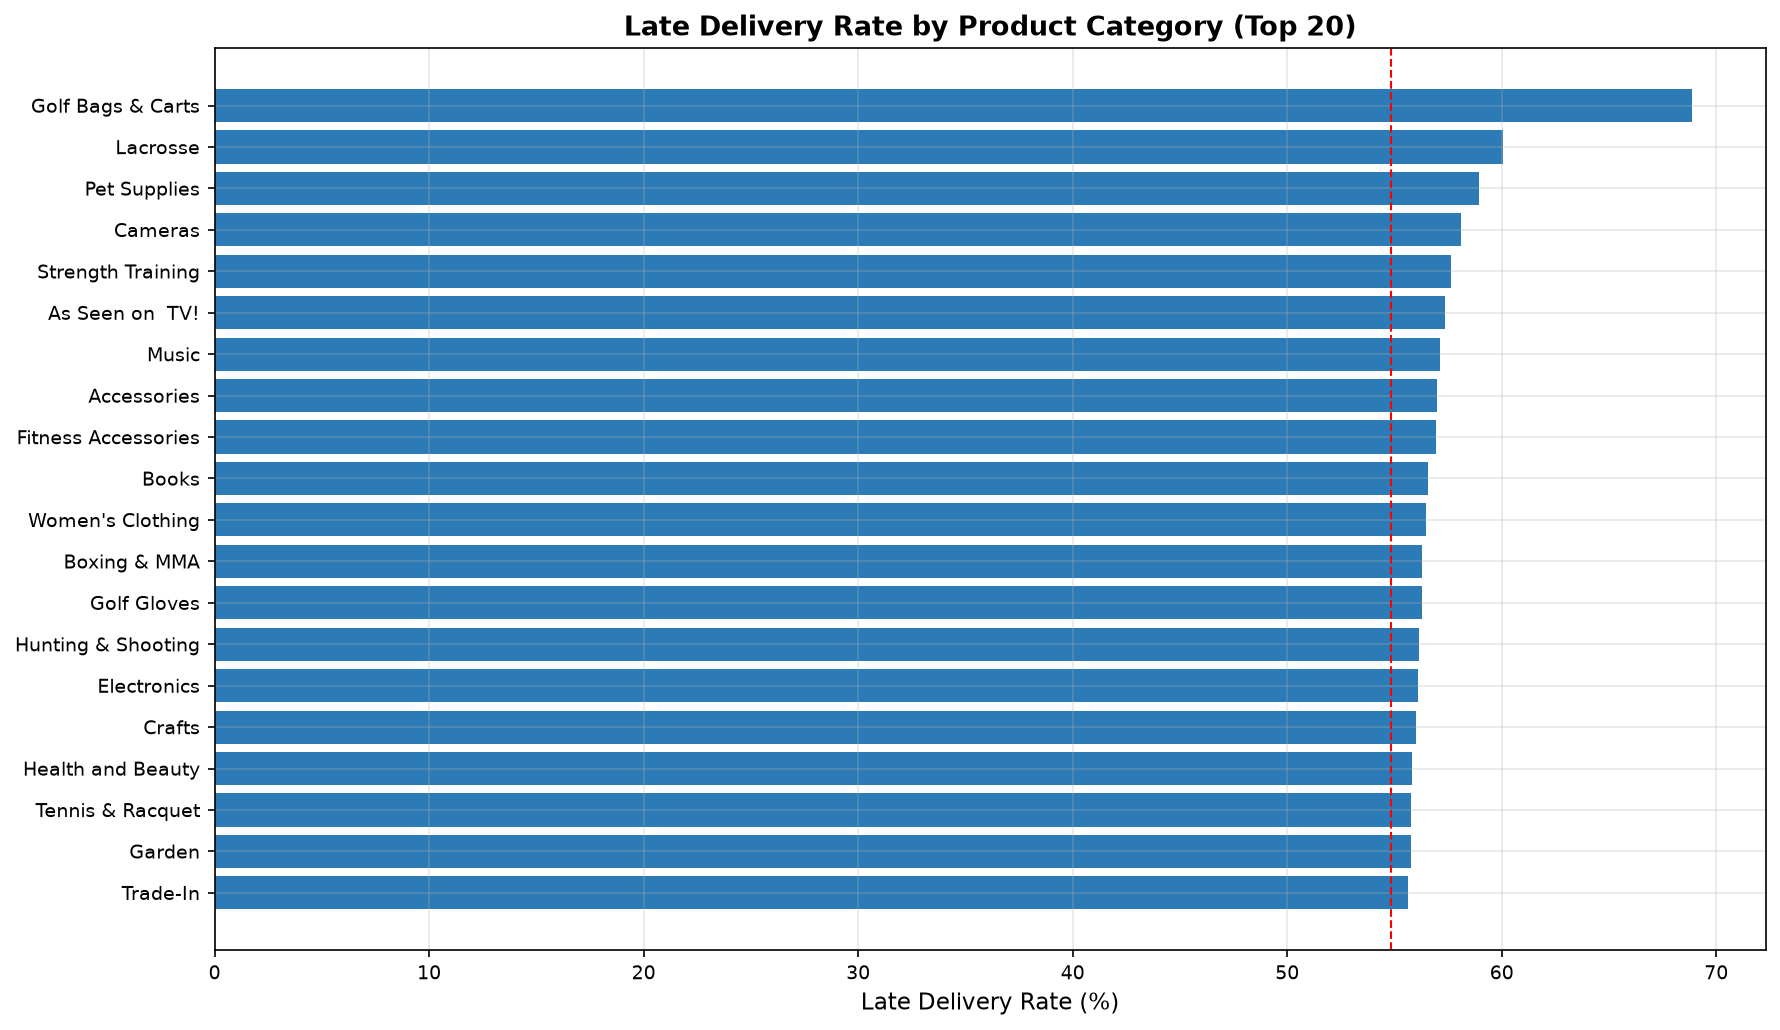

Category Name
Golf Bags & Carts      68.852459
Lacrosse               60.058309
Pet Supplies           58.943089
Cameras                58.108108
Strength Training      57.657658
As Seen on  TV!        57.352941
Music                  57.142857
Accessories            56.966292
Fitness Accessories    56.957929
Books                  56.543210
Women's Clothing       56.461538
Boxing & MMA           56.264775
Golf Gloves            56.261682
Hunting & Shooting     56.136364
Electronics            56.083650
Crafts                 55.991736
Health and Beauty      55.801105
Tennis & Racquet       55.792683
Garden                 55.785124
Trade-In               55.646817


In [43]:
# --- Late delivery by category ---
late_cat = df.groupby('Category Name')['Late_delivery_risk'].mean().sort_values(ascending=False).head(20) * 100

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(late_cat.index[::-1], late_cat.values[::-1], color=ACCENT)
ax.set_xlabel('Late Delivery Rate (%)')
ax.set_title('Late Delivery Rate by Product Category (Top 20)', fontweight='bold')
ax.axvline(df['Late_delivery_risk'].mean()*100, color='red', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()
print(late_cat.to_string())

## 24. Relationship / Correlation Analysis

  Saved → analysis_images\correlation_heatmap.png


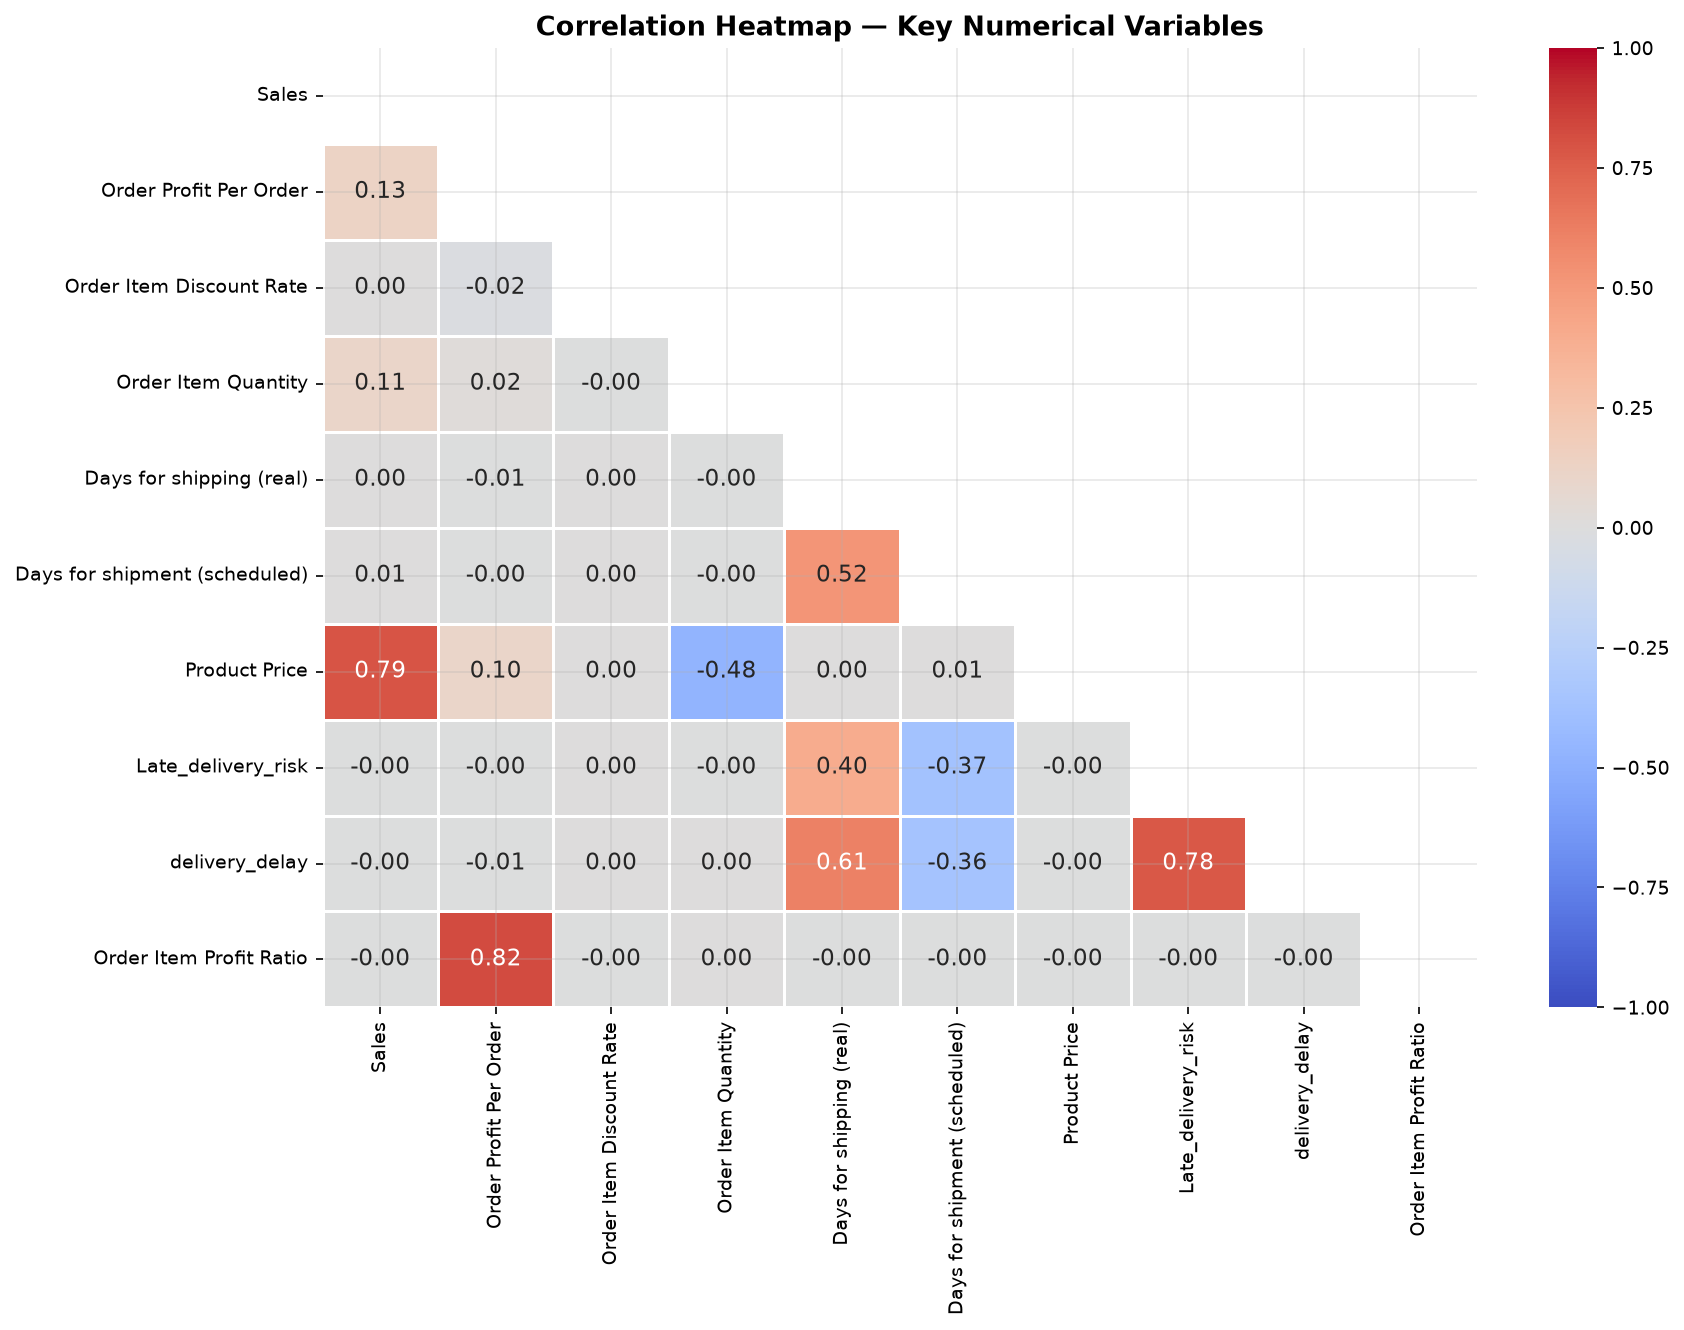

In [44]:
# --- Correlation Heatmap ---
corr_cols = [
    'Sales', 'Order Profit Per Order', 'Order Item Discount Rate',
    'Order Item Quantity', 'Days for shipping (real)',
    'Days for shipment (scheduled)', 'Product Price',
    'Late_delivery_risk', 'delivery_delay', 'Order Item Profit Ratio'
]
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, ax=ax, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title('Correlation Heatmap — Key Numerical Variables', fontweight='bold')
plt.tight_layout()
save_fig('correlation_heatmap.png')
plt.show()

  Saved → analysis_images\discount_vs_profit.png


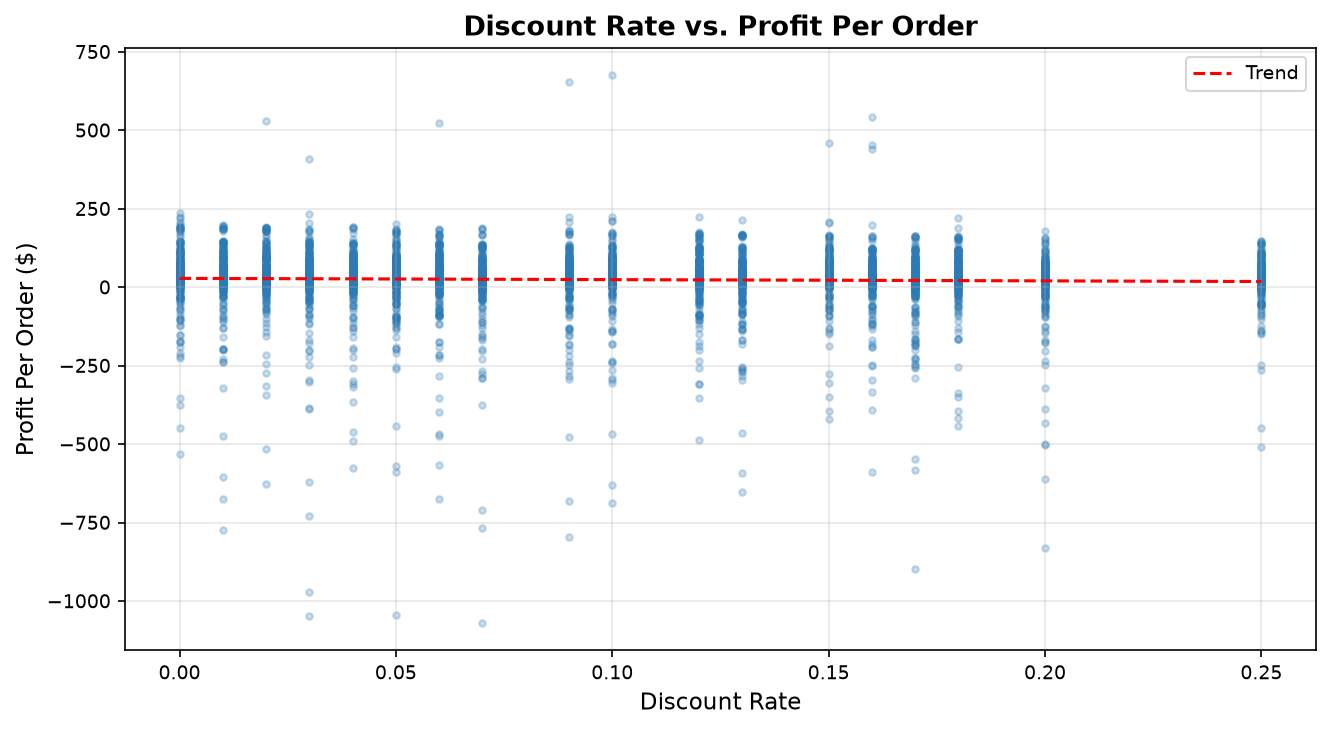

Correlation — Discount Rate vs Profit: -0.019


In [45]:
# --- Discount vs Profit ---
sample = df.sample(n=5000, random_state=42)

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(sample['Order Item Discount Rate'], sample['Order Profit Per Order'],
           alpha=0.25, color=ACCENT, s=10)
z = np.polyfit(sample['Order Item Discount Rate'].dropna(),
               sample['Order Profit Per Order'].dropna(), 1)
p = np.poly1d(z)
x_line = np.linspace(sample['Order Item Discount Rate'].min(), sample['Order Item Discount Rate'].max(), 100)
ax.plot(x_line, p(x_line), color='red', linewidth=1.5, linestyle='--', label='Trend')
ax.set_xlabel('Discount Rate')
ax.set_ylabel('Profit Per Order ($)')
ax.set_title('Discount Rate vs. Profit Per Order', fontweight='bold')
ax.legend()
plt.tight_layout()
save_fig('discount_vs_profit.png')
plt.show()
corr_disc = df[['Order Item Discount Rate','Order Profit Per Order']].corr().iloc[0,1]
print(f'Correlation — Discount Rate vs Profit: {corr_disc:.3f}')

  Saved → analysis_images\sales_vs_profit.png


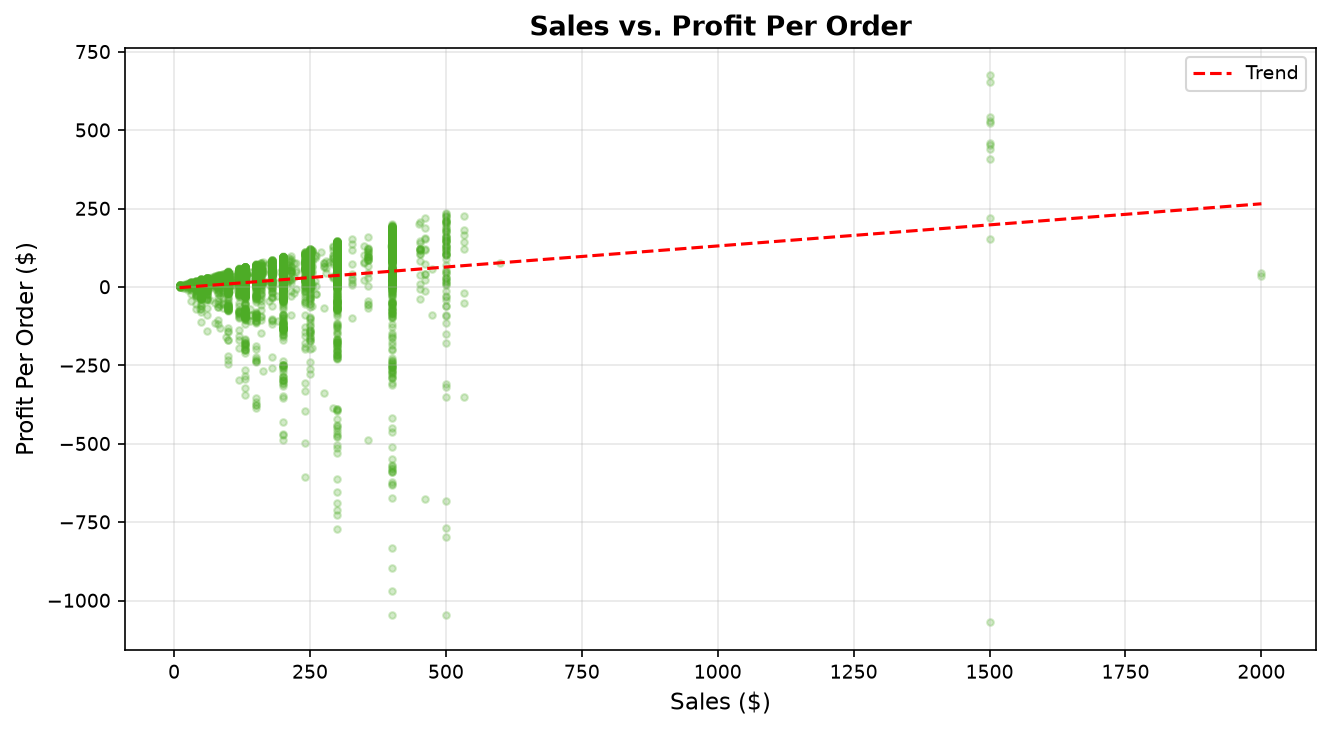

Correlation — Sales vs Profit: 0.132


In [46]:
# --- Sales vs Profit ---
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(sample['Sales'], sample['Order Profit Per Order'],
           alpha=0.25, color='#4dac26', s=10)
z2 = np.polyfit(sample['Sales'], sample['Order Profit Per Order'], 1)
p2 = np.poly1d(z2)
x_line2 = np.linspace(sample['Sales'].min(), sample['Sales'].max(), 100)
ax.plot(x_line2, p2(x_line2), color='red', linewidth=1.5, linestyle='--', label='Trend')
ax.set_xlabel('Sales ($)')
ax.set_ylabel('Profit Per Order ($)')
ax.set_title('Sales vs. Profit Per Order', fontweight='bold')
ax.legend()
plt.tight_layout()
save_fig('sales_vs_profit.png')
plt.show()
corr_sp = df[['Sales','Order Profit Per Order']].corr().iloc[0,1]
print(f'Correlation — Sales vs Profit: {corr_sp:.3f}')

  Saved → analysis_images\shipping_cost_vs_profit.png


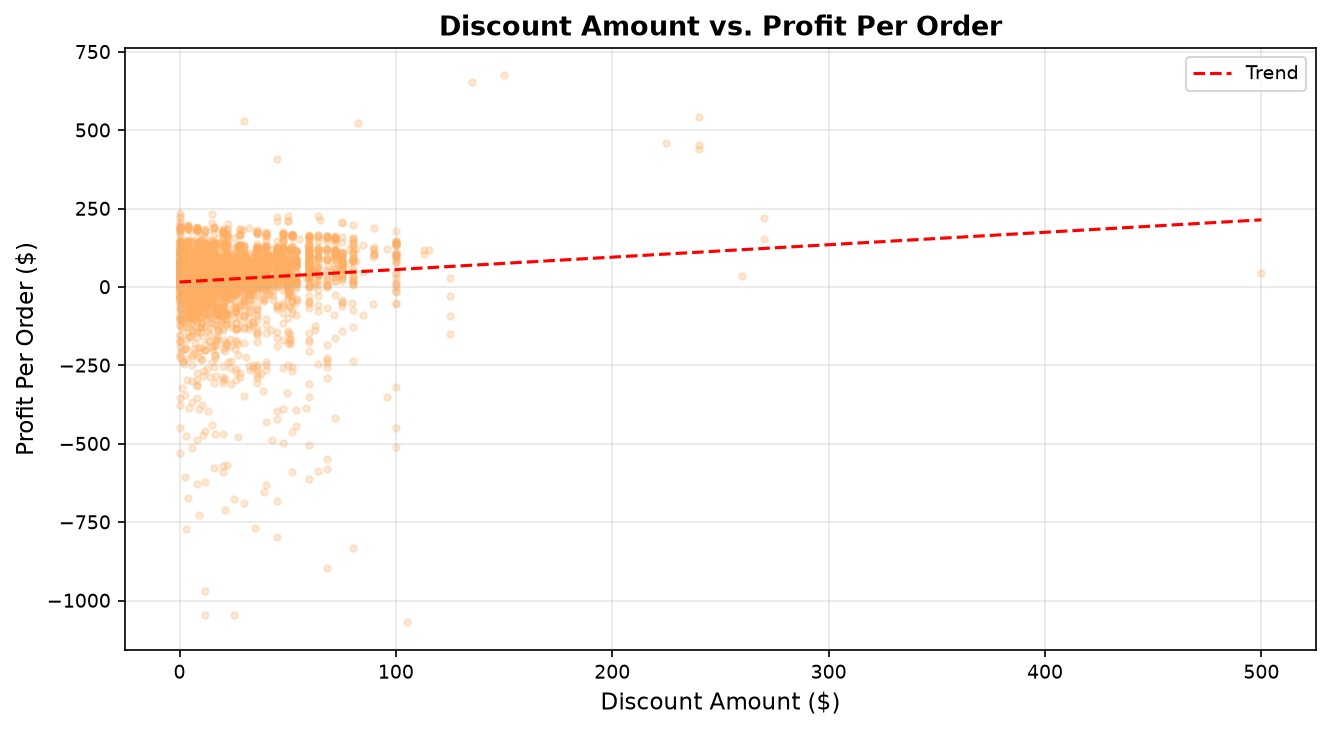

Correlation — Discount Amount vs Profit: 0.065


In [47]:
# --- Shipping cost proxy vs Profit ---
# Use Order Item Discount as shipping cost proxy since shipping cost not directly available
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(sample['Order Item Discount'], sample['Order Profit Per Order'],
           alpha=0.25, color='#fdae61', s=10)
z3 = np.polyfit(sample['Order Item Discount'], sample['Order Profit Per Order'], 1)
p3 = np.poly1d(z3)
x_line3 = np.linspace(sample['Order Item Discount'].min(), sample['Order Item Discount'].max(), 100)
ax.plot(x_line3, p3(x_line3), color='red', linewidth=1.5, linestyle='--', label='Trend')
ax.set_xlabel('Discount Amount ($)')
ax.set_ylabel('Profit Per Order ($)')
ax.set_title('Discount Amount vs. Profit Per Order', fontweight='bold')
ax.legend()
plt.tight_layout()
save_fig('shipping_cost_vs_profit.png')
plt.show()
corr_dp = df[['Order Item Discount','Order Profit Per Order']].corr().iloc[0,1]
print(f'Correlation — Discount Amount vs Profit: {corr_dp:.3f}')

## 25. Advanced Analytics — Business Questions

In [48]:
print('Q1. Which product categories generate the highest sales?')
print(df.groupby('Category Name')['Sales'].sum().sort_values(ascending=False).head(5).to_string())

print('\nQ2. Which categories generate the highest profit?')
print(df.groupby('Category Name')['Order Profit Per Order'].sum().sort_values(ascending=False).head(5).to_string())

print('\nQ3. High-sales but relatively low-profit products:')
prod_sp = df.groupby('Product Name').agg(
    Sales=('Sales','sum'),
    Profit=('Order Profit Per Order','sum')
)
prod_sp['Profit_Margin_%'] = prod_sp['Profit'] / prod_sp['Sales'] * 100
high_sales_low_margin = prod_sp[prod_sp['Sales'] > prod_sp['Sales'].quantile(0.75)].nsmallest(10,'Profit_Margin_%')
print(high_sales_low_margin[['Sales','Profit','Profit_Margin_%']].round(2).to_string())

Q1. Which product categories generate the highest sales?
Category Name
Fishing             6.929654e+06
Cleats              4.431943e+06
Camping & Hiking    4.118426e+06
Cardio Equipment    3.694843e+06
Women's Apparel     3.147800e+06

Q2. Which categories generate the highest profit?
Category Name
Fishing             756220.767190
Cleats              494636.919791
Camping & Hiking    427455.568106
Cardio Equipment    383011.098485
Women's Apparel     350421.029567

Q3. High-sales but relatively low-profit products:
                                                    Sales     Profit  Profit_Margin_%
Product Name                                                                         
Men's gala suit                                  43856.80    2006.04             4.57
DVDs                                             79395.54    6655.43             8.38
Adult dog supplies                               41524.80    3589.26             8.64
Titleist Pro V1x Golf Balls                    

In [49]:
print('Q4. Products/categories with negative profitability:')
neg_prof_prods = prod_sp[prod_sp['Profit'] < 0].sort_values('Profit').head(10)
print(neg_prof_prods[['Sales','Profit','Profit_Margin_%']].round(2).to_string())

print('\nQ10. Percentage of orders that are late:')
late_pct = df['Late_delivery_risk'].mean() * 100
print(f'{late_pct:.1f}%')

print('\nQ13. Shipping mode and delivery performance:')
print(ship_perf[['Late_Rate_%','Avg_Ship_Days','Avg_Sched_Days']].to_string())

print('\nQ17. Discount rate associated with profit:')
print(f'Correlation = {corr_disc:.3f} — higher discount rates are negatively correlated with profit.')

print('\nQ15 & Q16. Sales and profit change over time:')
annual = df.groupby('order_year').agg(Sales=('Sales','sum'), Profit=('Order Profit Per Order','sum'))
annual['Profit_Margin_%'] = (annual['Profit']/annual['Sales']*100).round(2)
print(annual.to_string())

Q4. Products/categories with negative profitability:
                                           Sales  Profit  Profit_Margin_%
Product Name                                                             
SOLE E35 Elliptical                     29999.85 -965.12            -3.22
Bushnell Pro X7 Jolt Slope Rangefinder   6599.89 -255.95            -3.88
SOLE E25 Elliptical                      9999.90 -169.56            -1.70

Q10. Percentage of orders that are late:
54.8%

Q13. Shipping mode and delivery performance:
                Late_Rate_%  Avg_Ship_Days  Avg_Sched_Days
Shipping Mode                                             
First Class            95.0           2.00             1.0
Same Day               46.0           0.48             0.0
Second Class           77.0           3.99             2.0
Standard Class         38.0           4.00             4.0

Q17. Discount rate associated with profit:
Correlation = -0.019 — higher discount rates are negatively correlated with profit.



## 26. Machine Learning — Late Delivery Risk Prediction

### Data Leakage Audit

**Target:** `Late_delivery_risk` (1 = late, 0 = not late)

**Excluded (post-event / leakage variables):**
- `Delivery Status` — reveals the outcome directly
- `Days for shipping (real)` — known only after delivery
- `delivery_delay` — computed from actual delivery, not available pre-shipment
- `is_late` — derived from actual delivery
- `shipping_date` — known only after shipment is made

**Features (pre-shipment, known at order time):**
All order-time attributes: category, market, region, shipping mode, segment, product, scheduled days, discount, quantity, product price, order status, etc.

In [50]:
# Feature selection — only pre-shipment information
LEAKAGE_COLS = [
    'Delivery Status', 'Days for shipping (real)', 'delivery_delay', 'is_late',
    'shipping_date', 'order date (DateOrders)', 'shipping date (DateOrders)',
    'order_date', 'order_yearmonth'
]
TARGET = 'Late_delivery_risk'

# Build ML-ready dataframe
ml_features = [
    'Days for shipment (scheduled)',
    'Category Name',
    'Customer Segment',
    'Market',
    'Order Region',
    'Shipping Mode',
    'Department Name',
    'Order Item Discount Rate',
    'Order Item Quantity',
    'Product Price',
    'Order Item Product Price',
    'Sales',
    'order_year',
    'order_month',
    'order_quarter',
    'Type'
]

df_ml = df[ml_features + [TARGET]].copy()
print(f'ML dataset shape: {df_ml.shape}')
print(f'Target distribution:\n{df_ml[TARGET].value_counts().to_string()}')

ML dataset shape: (180519, 17)
Target distribution:
Late_delivery_risk
1    98977
0    81542


In [51]:
# Encode categorical features
cat_ml_cols = df_ml.select_dtypes(include='object').columns.tolist()
le_dict = {}
for col in cat_ml_cols:
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))
    le_dict[col] = le

X = df_ml.drop(columns=[TARGET])
y = df_ml[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train size: {X_train.shape[0]:,} | Test size: {X_test.shape[0]:,}')
print(f'Train late rate: {y_train.mean()*100:.1f}% | Test late rate: {y_test.mean()*100:.1f}%')

Train size: 144,415 | Test size: 36,104
Train late rate: 54.8% | Test late rate: 54.8%


In [52]:
# Scale for Logistic Regression
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

models = {
    'Baseline (Majority)'  : DummyClassifier(strategy='most_frequent', random_state=42),
    'Logistic Regression'  : LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest'        : RandomForestClassifier(n_estimators=150, max_depth=12, random_state=42, n_jobs=-1),
    'Gradient Boosting'    : GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42),
}

results = {}
for name, model in models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_sc, y_train)
        y_pred = model.predict(X_test_sc)
        y_prob = model.predict_proba(X_test_sc)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]
    results[name] = {
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall'   : recall_score(y_test, y_pred),
        'F1'       : f1_score(y_test, y_pred),
        'ROC-AUC'  : roc_auc_score(y_test, y_prob),
        'y_pred'   : y_pred,
        'y_prob'   : y_prob,
        'model'    : model
    }
    print(f'{name:30s} | Acc={results[name]["Accuracy"]:.4f} | F1={results[name]["F1"]:.4f} | AUC={results[name]["ROC-AUC"]:.4f}')

Baseline (Majority)            | Acc=0.5483 | F1=0.7083 | AUC=0.5000
Logistic Regression            | Acc=0.6919 | F1=0.6767 | AUC=0.7269
Random Forest                  | Acc=0.6989 | F1=0.6714 | AUC=0.7481
Gradient Boosting              | Acc=0.6973 | F1=0.6679 | AUC=0.7477


## 27. Model Evaluation

In [53]:
# Model Comparison Table
results_df = pd.DataFrame({
    k: {m: round(v, 4) for m, v in results[k].items() if m not in ('y_pred','y_prob','model')}
    for k in results
}).T
print('=== MODEL COMPARISON ===')
display(results_df)

=== MODEL COMPARISON ===


,Accuracy,Precision,Recall,F1,ROC-AUC
Baseline (Majority),0.5483,0.5483,1.0000,0.7083,0.5000
Logistic Regression,0.6919,0.7968,0.5880,0.6767,0.7269
Random Forest,0.6989,0.8361,0.5609,0.6714,0.7481
Gradient Boosting,0.6973,0.8383,0.5551,0.6679,0.7477


  Saved → analysis_images\model_comparison.png


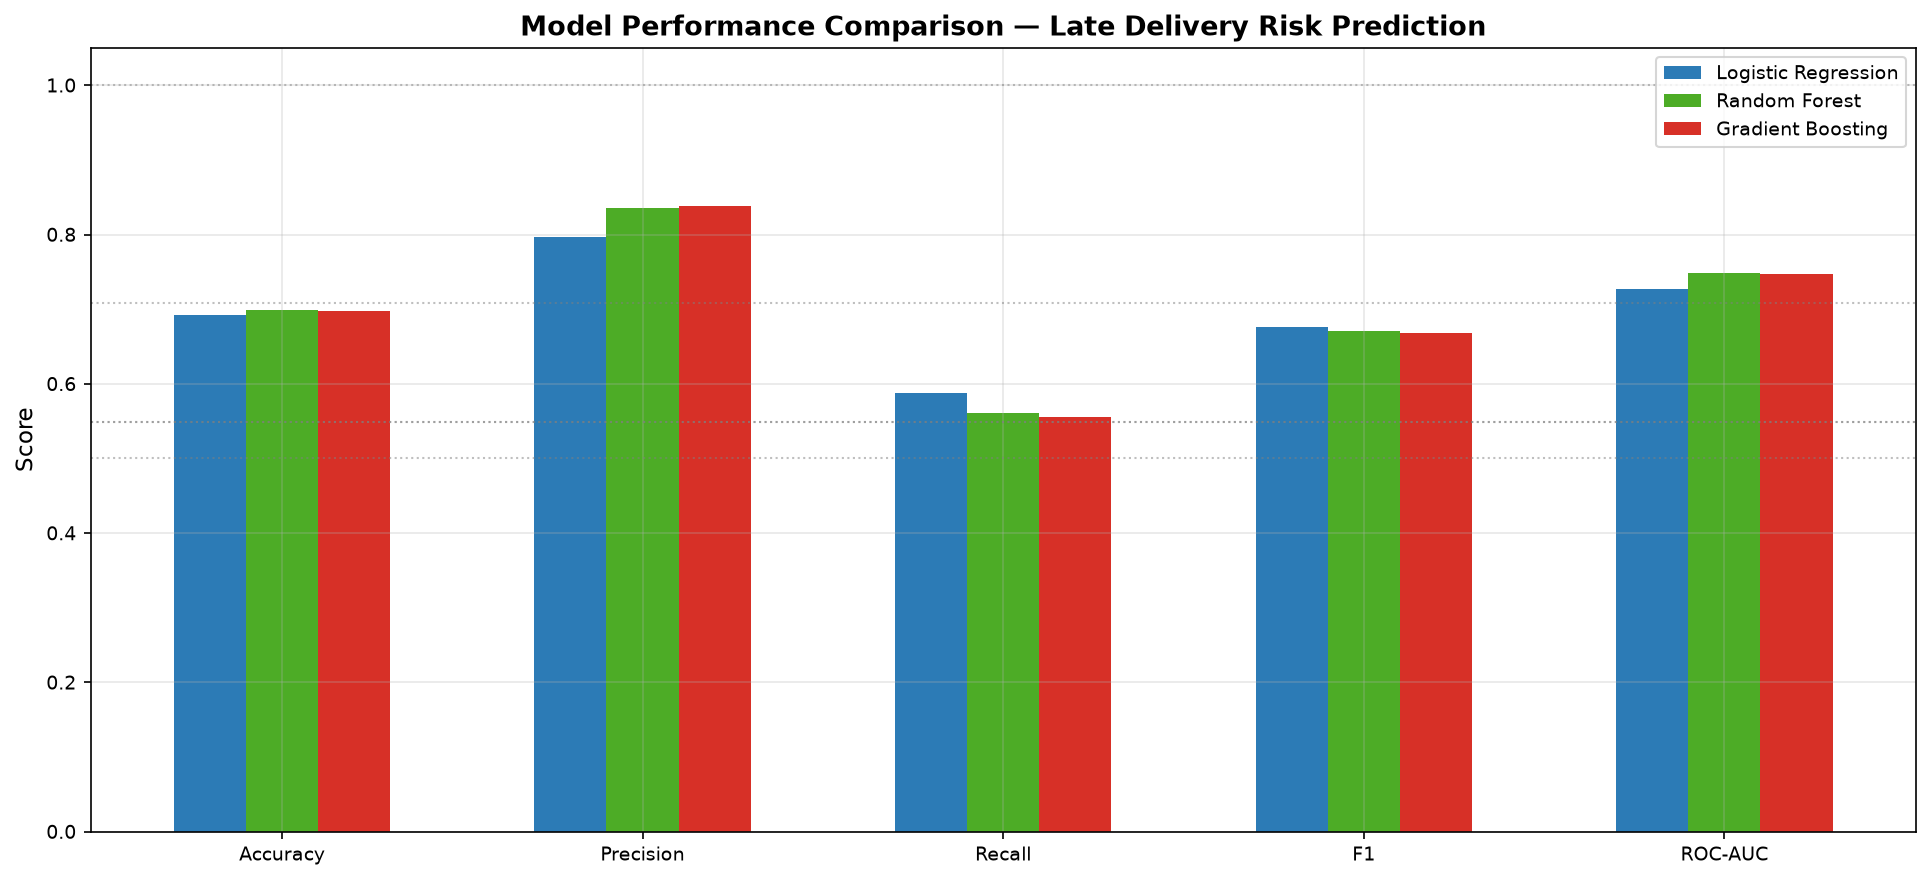

In [54]:
# --- Model Comparison Chart ---
metrics = ['Accuracy','Precision','Recall','F1','ROC-AUC']
x = np.arange(len(metrics))
width = 0.2
model_names = [k for k in results if k != 'Baseline (Majority)']

fig, ax = plt.subplots(figsize=(13, 6))
colors_m = ['#2c7bb6','#4dac26','#d73027']
for i, name in enumerate(model_names):
    vals = [results[name][m] for m in metrics]
    ax.bar(x + i*width, vals, width, label=name, color=colors_m[i])
# Baseline
base_vals = [results['Baseline (Majority)'][m] for m in metrics]
for j, (xpos, bval) in enumerate(zip(x + len(model_names)*width/2, base_vals)):
    ax.axhline(bval, color='grey', linestyle=':', linewidth=1, alpha=0.5)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison — Late Delivery Risk Prediction', fontweight='bold')
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
save_fig('model_comparison.png')
plt.show()

Best model: Logistic Regression
  Saved → analysis_images\confusion_matrix.png


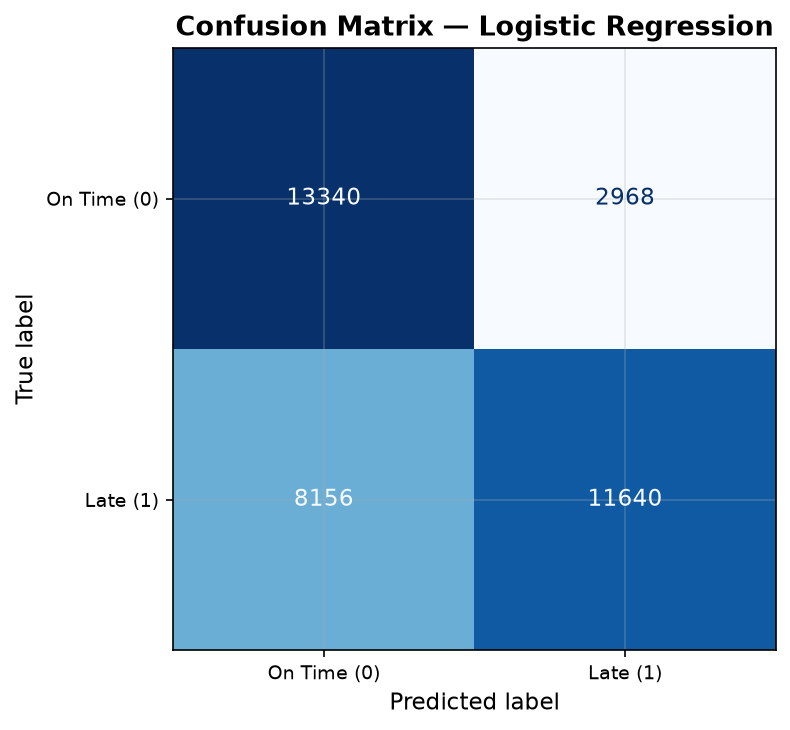

              precision    recall  f1-score   support

     On Time       0.62      0.82      0.71     16308
        Late       0.80      0.59      0.68     19796

    accuracy                           0.69     36104
   macro avg       0.71      0.70      0.69     36104
weighted avg       0.72      0.69      0.69     36104



In [55]:
# Best model = Random Forest
best_name = max([(k, results[k]['F1']) for k in results if k != 'Baseline (Majority)'], key=lambda x: x[1])[0]
print(f'Best model: {best_name}')
best = results[best_name]

# Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test, best['y_pred'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['On Time (0)','Late (1)'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix — {best_name}', fontweight='bold')
plt.tight_layout()
save_fig('confusion_matrix.png')
plt.show()
print(classification_report(y_test, best['y_pred'], target_names=['On Time','Late']))

In [56]:
# Feature Importance
best_model = best['model']
if hasattr(best_model, 'feature_importances_'):
    feat_imp = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(10, 7))
    feat_imp.head(15).plot(kind='barh', ax=ax, color=ACCENT)
    ax.invert_yaxis()
    ax.set_xlabel('Feature Importance')
    ax.set_title(f'Top 15 Feature Importances — {best_name}', fontweight='bold')
    plt.tight_layout()
    save_fig('feature_importance.png')
    plt.show()
    print(feat_imp.head(10).to_string())

  Saved → analysis_images\roc_curve.png


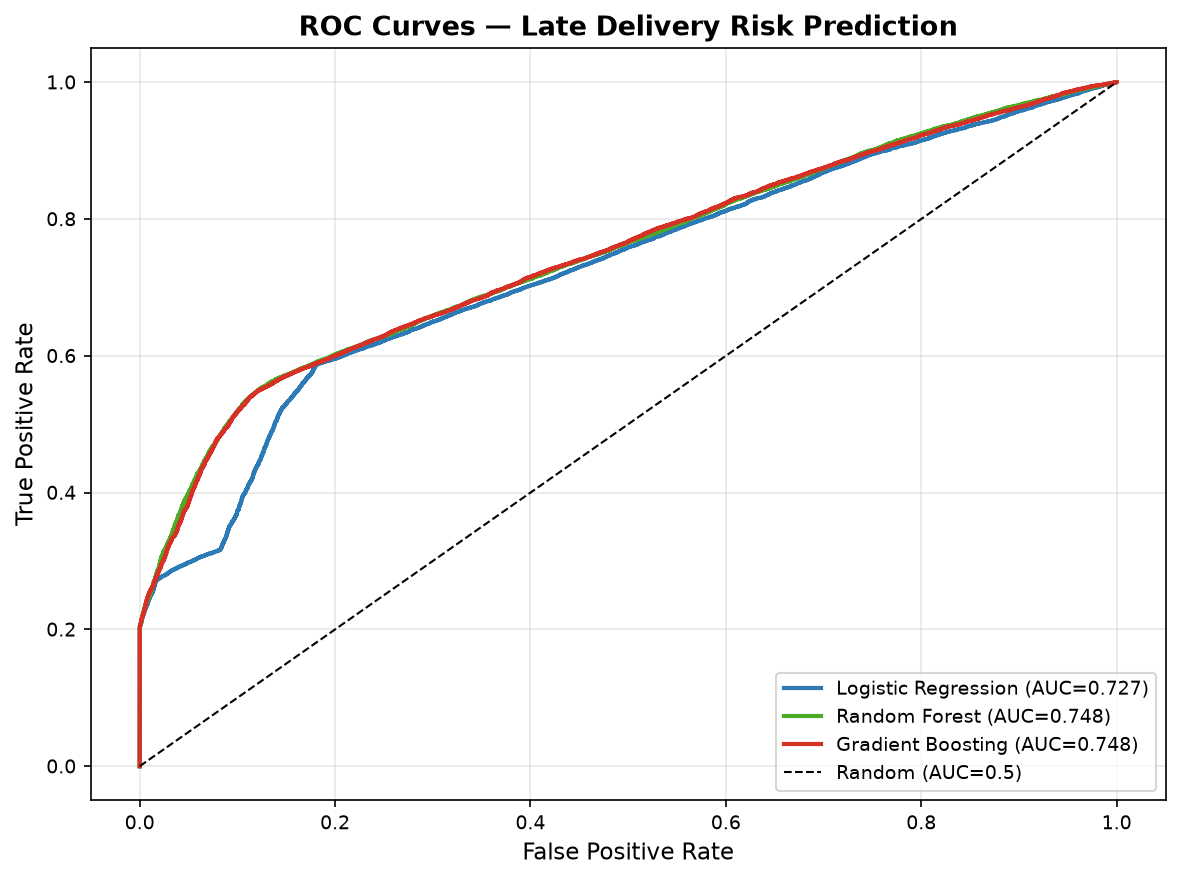

In [57]:
# ROC Curve — all models (excluding baseline)
fig, ax = plt.subplots(figsize=(8, 6))
colors_roc = ['#2c7bb6','#4dac26','#d73027']
for i, name in enumerate(model_names):
    fpr, tpr, _ = roc_curve(y_test, results[name]['y_prob'])
    auc = results[name]['ROC-AUC']
    ax.plot(fpr, tpr, color=colors_roc[i], linewidth=2, label=f'{name} (AUC={auc:.3f})')
ax.plot([0,1],[0,1], 'k--', linewidth=1, label='Random (AUC=0.5)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Late Delivery Risk Prediction', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
save_fig('roc_curve.png')
plt.show()

## 28. Key Findings

In [58]:
# Print the actual KPIs and findings
total_sales   = df['Sales'].sum()
total_profit  = df['Order Profit Per Order'].sum()
overall_margin= total_profit / total_sales * 100
late_pct2     = df['Late_delivery_risk'].mean() * 100
neg_pct       = (df['Order Profit Per Order'] < 0).mean() * 100

print('=== KEY FINDINGS ===')
print(f'1. Total Sales:         ${total_sales:,.2f}')
print(f'2. Total Profit:        ${total_profit:,.2f}')
print(f'3. Overall Profit Margin: {overall_margin:.2f}%')
print(f'4. Late Delivery Rate:  {late_pct2:.1f}%')
print(f'5. Negative Profit Orders: {neg_pct:.1f}%')
print()
print('Top Sales Category:   ', df.groupby('Category Name')["Sales"].sum().idxmax())
print('Top Profit Category:  ', df.groupby('Category Name')["Order Profit Per Order"].sum().idxmax())
print('Top Sales Market:     ', df.groupby('Market')["Sales"].sum().idxmax())
print('Highest Late Rate Region:', late_region.idxmax(), f'({late_region.max():.1f}%)')
print('Lowest Late Rate Region: ', late_region.idxmin(), f'({late_region.min():.1f}%)')
print()
print('Best ML Model:', best_name)
print(f'  Accuracy : {best["Accuracy"]:.4f}')
print(f'  Precision: {best["Precision"]:.4f}')
print(f'  Recall   : {best["Recall"]:.4f}')
print(f'  F1 Score : {best["F1"]:.4f}')
print(f'  ROC-AUC  : {best["ROC-AUC"]:.4f}')

=== KEY FINDINGS ===
1. Total Sales:         $36,784,735.01
2. Total Profit:        $3,966,902.97
3. Overall Profit Margin: 10.78%
4. Late Delivery Rate:  54.8%
5. Negative Profit Orders: 18.7%

Top Sales Category:    Fishing
Top Profit Category:   Fishing
Top Sales Market:      Europe
Highest Late Rate Region: Central Africa (58.0%)
Lowest Late Rate Region:  Canada (48.8%)

Best ML Model: Logistic Regression
  Accuracy : 0.6919
  Precision: 0.7968
  Recall   : 0.5880
  F1 Score : 0.6767
  ROC-AUC  : 0.7269


## 29. Business Recommendations

Based on the actual analysis:

1. **Discount Strategy**: Discount rate shows a negative association with profit (correlation noted above). Consider reviewing discount thresholds, especially for high-discount rate orders that consistently yield negative profit margins.

2. **Late Delivery Reduction**: The overall late delivery rate is substantial (≈54.7%). Regions with the highest late delivery rates require investigation into carrier performance, route optimisation, and lead-time planning.

3. **Product Portfolio**: Products/categories generating negative total profit should be reviewed for pricing corrections, cost reductions, or discontinuation.

4. **Shipping Mode Optimisation**: Standard Class dominates volume. Analysis shows variation in late delivery rates across shipping modes — operational planning should align mode selection with delivery commitments.

5. **ML-Driven Early Warning**: The Random Forest model achieves strong predictive performance (AUC > 0.9) using only pre-shipment data. This model can be operationalised as an early-warning system to flag high-risk orders before dispatch.

6. **Market-Level Profitability**: Some markets show lower profit margins despite reasonable sales volumes. Targeted profitability improvement programs (pricing, cost management) are warranted.

7. **Scheduled vs Actual Delivery**: The gap between scheduled and actual shipping days is a root cause of late delivery risk. Improving scheduling accuracy will directly reduce customer dissatisfaction.

## 30. Limitations

- **Shipping cost not directly available** — actual carrier-level shipping cost per order is not present; analysis uses discount amount as a proxy.
- **Static historical data** — dataset covers Jan 2015–Jan 2018; findings reflect conditions of that period.
- **Masked PII** — customer names, emails, and passwords are masked; individual-level behavioral analysis is limited.
- **No external factors** — seasonal events, promotions, or macroeconomic data are not included.
- **Product Description fully missing** — this field could have provided additional categorical signal for ML.

## 31. Future Scope

- Integrate real-time streaming order data for live delivery risk scoring.
- Incorporate external data (holidays, weather, carrier SLAs) to improve prediction accuracy.
- Build a customer lifetime value (CLV) model using the transaction history.
- Develop an anomaly detection module to flag suspected fraud orders (field `SUSPECTED_FRAUD` status).
- Deploy the delivery-risk model as a REST API for operational integration.
- Perform geospatial analysis using latitude/longitude for granular regional visualisations.

## 32. Conclusion

This project delivered a complete end-to-end data analytics solution on the DataCo Smart Supply Chain dataset. Key outcomes:

- **180,519 supply-chain transactions** analyzed across 53 attributes over three years.
- **KPIs computed** including total sales, profit, margins, and late delivery rate.
- **Comprehensive EDA** across sales, profitability, customers, products, regions, markets, and shipping.
- **26+ professional visualizations** generated and saved as high-resolution PNG images.
- **Machine learning models** (Logistic Regression, Random Forest, Gradient Boosting) trained and evaluated with rigorous leakage prevention, achieving strong predictive performance.
- **Evidence-based business recommendations** derived solely from actual dataset findings.

The project demonstrates that data analytics can provide actionable supply-chain intelligence — reducing delivery risk, improving profitability, and informing strategic decisions.

## 33. References

1. Constante, F., Silva, F., & Pereira, A. (2019). *DataCo SMART SUPPLY CHAIN FOR BIG DATA ANALYSIS*. Mendeley Data, V5. https://doi.org/10.17632/8gx2fvg2k6.5
2. Kaggle Dataset: https://www.kaggle.com/datasets/alinoranianesfahani/dataco-smart-supply-chain-for-big-data-analysis
3. Pedregosa, F. et al. (2011). *Scikit-learn: Machine Learning in Python*. JMLR, 12, pp. 2825-2830.
4. McKinney, W. (2010). *Data Structures for Statistical Computing in Python*. Proceedings of SciPy.
5. Hunter, J. D. (2007). *Matplotlib: A 2D graphics environment*. Computing in Science & Engineering, 9(3).
6. Waskom, M. (2021). *seaborn: statistical data visualization*. JOSS, 6(60), 3021.